# 🐼 Pandas + Statistics 
### A Complete Hands-On Guide — From First Principles to Real-World Analysis

This notebook is the comprehensive companion to the introductory pandas guide. It is designed to take you from the absolute basics of the library all the way to the statistical and probabilistic foundations a working data scientist relies on every day.

---

## 📚 Table of Contents

### Part I — Core Pandas
1. Introduction & Setup
2. The Series Object (in depth)
3. The DataFrame Object (in depth)
4. Reading & Writing Data
5. Inspecting Data
6. Selection & Indexing (`loc`, `iloc`, boolean, query)
7. Filtering & Querying
8. Modifying DataFrames
9. Handling Missing Data
10. Data Types & Type Conversion

### Part II — Intermediate Pandas
11. String Operations (the `.str` accessor)
12. DateTime Operations (the `.dt` accessor)
13. `apply`, `map`, and `transform`
14. GroupBy & Aggregation
15. Joining, Merging & Concatenation
16. Reshaping Data (`pivot`, `melt`, `stack`)
17. Sorting & Ranking
18. Window Functions & Rolling Statistics
19. Time Series Operations
20. Categorical Data
21. Performance & Memory

### Part III — Statistics & Probability
22. Descriptive Statistics
23. Probability Distributions
24. Probability Concepts (joint, marginal, conditional)
25. Correlation & Covariance
26. Sampling Techniques
27. Hypothesis Testing & Statistical Tests
28. Confidence Intervals
29. Outlier Detection
30. End-to-End EDA Case Study

---

> **How to use this notebook:** read top to bottom for a complete walkthrough, or jump to any section as a reference. Every concept is paired with runnable code on a real dataset (Titanic) so you can experiment freely.

---
## 1. Introduction & Setup

**Pandas** is the foundational library for tabular data in Python. The name comes from *panel data*, an econometrics term for multidimensional datasets. At its core, pandas offers two data structures:

- **`Series`** — a one-dimensional labeled array, like a single column of a spreadsheet
- **`DataFrame`** — a two-dimensional labeled table, like a whole spreadsheet or SQL table

Pandas is built on top of NumPy, which means it inherits NumPy's speed for numerical work while adding flexible row/column labels, missing-data handling, time-series features, and a vast ecosystem of utilities for data cleaning, reshaping, joining, and summarization.

### Why data scientists rely on pandas
- **Read almost any format**: CSV, Excel, JSON, Parquet, SQL, HTML — pandas reads it
- **Handle messy data**: missing values, mixed types, duplicates, inconsistent labels
- **Group and aggregate**: SQL-like grouping with one line of code
- **Time series**: native support for dates, resampling, windows
- **Integrates with everything**: matplotlib, scikit-learn, statsmodels, NumPy, PyTorch

### Installation
```bash
pip install pandas numpy matplotlib seaborn scipy
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

np.random.seed(42)
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
print(f"scipy:   {__import__('scipy').__version__}")
print(f"seaborn: {sns.__version__}")

pandas:  3.0.3
numpy:   2.4.6
scipy:   1.18.0
seaborn: 0.13.2


In [2]:
def load_titanic():
    """Load titanic and add synthetic passenger names for string-operation examples."""
    t = sns.load_dataset('titanic')
    if 'name' not in t.columns:
        surnames = ['Smith','Brown','Allen','Andrews','Bird','Carter','Davies','Evans',
                    'Fitzgerald','Gordon','Harris','Jones','Kelly','Lewis','Martin',
                    'Nelson','O\'Brien','Phillips','Quinn','Roberts','Stewart','Taylor']
        male_first = ['John','William','James','George','Charles','Henry','Frank']
        female_first = ['Mary','Anna','Elizabeth','Margaret','Alice','Helen','Catherine']
        rng = np.random.default_rng(42)
        names = []
        for _, row in t.iterrows():
            sur = rng.choice(surnames)
            if row['who'] == 'child':
                title = 'Master' if row['sex'] == 'male' else 'Miss'
            elif row['sex'] == 'male':
                title = 'Mr'
            else:
                title = 'Mrs' if row.get('parch', 0) > 0 else 'Miss'
            first = rng.choice(male_first if row['sex']=='male' else female_first)
            names.append(f"{sur}, {title}. {first}")
        t.insert(0, 'name', names)
    return t

### 💡 About `pd.set_option`

Pandas has display behavior controlled by global options — exactly like matplotlib's `rcParams`. The most commonly tweaked ones:

| Option | Purpose |
|--------|---------|
| `display.max_rows` | How many rows are shown for big DataFrames (default 60) |
| `display.max_columns` | How many columns are shown (default 20) |
| `display.width` | Console width before wrapping |
| `display.float_format` | How float numbers are formatted |
| `display.precision` | Decimal places for floats |

Use `pd.reset_option('all')` to restore defaults.

---
## 2. The Series Object — In Depth

A **`Series`** is a one-dimensional labeled array. Think of it as a column from a spreadsheet that also has a list of row labels (the **index**). Every value has a position (0, 1, 2…) **and** a label.

### Anatomy of a Series

```
Index    Values
─────    ──────
'a'  →     10
'b'  →     20
'c'  →     30
```

You can access elements **by label** (`s['a']`) or **by position** (`s.iloc[0]`).

### 2.1 Creating a Series — every way

In [3]:
# From a Python list — index defaults to 0, 1, 2, ...
s1 = pd.Series([10, 20, 30, 40])
print(s1)

0    10
1    20
2    30
3    40
dtype: int64


In [4]:
# From a list with a custom index
s2 = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'], name='my_series')
print(s2)

a    10
b    20
c    30
d    40
Name: my_series, dtype: int64


In [5]:
# From a Python dictionary — keys become the index
s3 = pd.Series({'Ram': 90, 'Hari': 86.5, 'Gita': 87.3, 'Sita': 92})
print(s3)

Ram    90.0000
Hari   86.5000
Gita   87.3000
Sita   92.0000
dtype: float64


In [6]:
# From a NumPy array
arr = np.array([1.5, 2.7, 3.1, 4.9])
s4 = pd.Series(arr, index=['w', 'x', 'y', 'z'])
print(s4)

w   1.5000
x   2.7000
y   3.1000
z   4.9000
dtype: float64


In [7]:
# From a scalar — broadcast across the index
s5 = pd.Series(0.0, index=['a', 'b', 'c', 'd', 'e'])
print(s5)

a   0.0000
b   0.0000
c   0.0000
d   0.0000
e   0.0000
dtype: float64


### 2.2 Key attributes of a Series

Every Series exposes a handful of attributes you'll use constantly:

In [8]:
s = pd.Series([10, 20, 30, 40, 50],
              index=['a', 'b', 'c', 'd', 'e'],
              name='measurements')

print(f"values  : {s.values}          # underlying NumPy array")
print(f"index   : {list(s.index)}")
print(f"name    : {s.name}")
print(f"dtype   : {s.dtype}            # data type of values")
print(f"size    : {s.size}             # total number of elements")
print(f"shape   : {s.shape}            # (length,) tuple")
print(f"ndim    : {s.ndim}             # always 1 for a Series")

values  : [10 20 30 40 50]          # underlying NumPy array
index   : ['a', 'b', 'c', 'd', 'e']
name    : measurements
dtype   : int64            # data type of values
size    : 5             # total number of elements
shape   : (5,)            # (length,) tuple
ndim    : 1             # always 1 for a Series


### 2.3 Indexing & slicing — by label and by position

This is where many beginners get confused. There are **two parallel systems**:

| Access pattern | Uses the... | Recommended accessor |
|----------------|------------|----------------------|
| By **label** (`s['a']`) | string/whatever label | `.loc[...]` |
| By **position** (`s[0]`) | integer position 0..n-1 | `.iloc[...]` |

Bare indexing like `s['a']` or `s[0]` works, but is ambiguous when the index itself is integer-labeled. **Use `.loc` and `.iloc` to be explicit.**

In [9]:
# Label-based access
print(f"s.loc['a']      = {s.loc['a']}")
print(f"s.loc['b':'d']  =\n{s.loc['b':'d']}")
# Note: with .loc, the END label IS included (unlike Python lists!)

s.loc['a']      = 10
s.loc['b':'d']  =
b    20
c    30
d    40
Name: measurements, dtype: int64


In [10]:
# Position-based access
print(f"s.iloc[0]    = {s.iloc[0]}")
print(f"s.iloc[1:3]  =\n{s.iloc[1:3]}")
# With .iloc, the END position is excluded (standard Python behavior)

s.iloc[0]    = 10
s.iloc[1:3]  =
b    20
c    30
Name: measurements, dtype: int64


In [11]:
# Fancy indexing — pass a list of labels or positions
print(s.loc[['a', 'c', 'e']])
print()
print(s.iloc[[0, 2, 4]])

a    10
c    30
e    50
Name: measurements, dtype: int64

a    10
c    30
e    50
Name: measurements, dtype: int64


### 2.4 Vectorized operations on a Series

Series operations are **vectorized** — applied to every element at once. This is far faster than a Python loop.

In [12]:
prices = pd.Series([100, 250, 75, 400, 150], name='price')

# Arithmetic with a scalar
print("With 8% tax:")
print((prices * 1.08).round(2))
print()
# Element-wise comparison
print("Expensive items (>200):")
print(prices > 200)

With 8% tax:
0   108.0000
1   270.0000
2    81.0000
3   432.0000
4   162.0000
Name: price, dtype: float64

Expensive items (>200):
0    False
1     True
2    False
3     True
4    False
Name: price, dtype: bool


In [13]:
# Two Series — operations align by index automatically
a = pd.Series([1, 2, 3, 4], index=['w', 'x', 'y', 'z'])
b = pd.Series([10, 20, 30], index=['x', 'y', 'z'])
print("a + b (aligned by index, missing labels → NaN):")
print(a + b)

a + b (aligned by index, missing labels → NaN):
w       NaN
x   12.0000
y   23.0000
z   34.0000
dtype: float64


> **Critical concept:** pandas aligns by **index labels**, not position. This is one of the most powerful — and surprising — features of pandas.

---
## 3. The DataFrame Object — In Depth

A **`DataFrame`** is a 2D labeled table. Each column is a Series, and all columns share the same row index.

```
        col_A    col_B    col_C
row1     1.0     'cat'      True
row2     2.5     'dog'      False
row3     3.7     'bird'     True
```

A DataFrame has:
- A **row index** (one label per row)
- **Column names** (one label per column)
- **Values** (a 2D block of data, possibly with different dtypes per column)

### 3.1 Creating DataFrames — every way

In [14]:
# From a dictionary of lists — most common
df1 = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Carol', 'Dan'],
    'age': [25, 30, 35, 40],
    'city': ['Kathmandu', 'Pokhara', 'Lalitpur', 'Bhaktapur'],
    'salary': [50000, 60000, 75000, 90000]
})
df1

,name,age,city,salary
0,Alice,25,Kathmandu,50000
1,Bob,30,Pokhara,60000
2,Carol,35,Lalitpur,75000
3,Dan,40,Bhaktapur,90000


In [15]:
# From a list of dictionaries — each dict becomes a row
records = [
    {'name': 'Alice', 'age': 25, 'city': 'Kathmandu'},
    {'name': 'Bob', 'age': 30, 'city': 'Pokhara'},
    {'name': 'Carol', 'age': 35},                    # missing 'city' → NaN
]
df2 = pd.DataFrame(records)
df2

,name,age,city
0,Alice,25,Kathmandu
1,Bob,30,Pokhara
2,Carol,35,NaN


In [16]:
# From a list of lists — pass column names separately
data = [
    ['Alice', 25, 'Kathmandu'],
    ['Bob', 30, 'Pokhara'],
    ['Carol', 35, 'Lalitpur'],
]
df3 = pd.DataFrame(data, columns=['name', 'age', 'city'])
df3

,name,age,city
0,Alice,25,Kathmandu
1,Bob,30,Pokhara
2,Carol,35,Lalitpur


In [17]:
# From a NumPy array — useful when data is purely numerical
arr = np.random.randn(4, 3)
df4 = pd.DataFrame(arr, columns=['x', 'y', 'z'], index=['r1', 'r2', 'r3', 'r4'])
df4.round(3)

,x,y,z
r1,0.4970,-0.1380,0.6480
r2,1.5230,-0.2340,-0.2340
r3,1.5790,0.7670,-0.4690
r4,0.5430,-0.4630,-0.4660


In [18]:
# From multiple Series — they align on their indices
s_age = pd.Series([25, 30, 35], index=['Alice', 'Bob', 'Carol'])
s_sal = pd.Series([50000, 60000, 75000, 90000],
                  index=['Alice', 'Bob', 'Carol', 'Dan'])
df5 = pd.DataFrame({'age': s_age, 'salary': s_sal})
df5  # Dan has no age → NaN

,age,salary
Alice,25.0000,50000
Bob,30.0000,60000
Carol,35.0000,75000
Dan,NaN,90000


### 3.2 Key attributes of a DataFrame

In [19]:
df = df1.copy()
print(f"shape        : {df.shape}")
print(f"size         : {df.size}             # total cells")
print(f"ndim         : {df.ndim}             # always 2")
print(f"columns      : {list(df.columns)}")
print(f"index        : {list(df.index)}")
print(f"dtypes       :\n{df.dtypes}")

shape        : (4, 4)
size         : 16             # total cells
ndim         : 2             # always 2
columns      : ['name', 'age', 'city', 'salary']
index        : [0, 1, 2, 3]
dtypes       :
name        str
age       int64
city        str
salary    int64
dtype: object


In [20]:
# .values returns the underlying 2D NumPy array (modern preference: .to_numpy())
print(df.to_numpy())

[['Alice' 25 'Kathmandu' 50000]
 ['Bob' 30 'Pokhara' 60000]
 ['Carol' 35 'Lalitpur' 75000]
 ['Dan' 40 'Bhaktapur' 90000]]


### 3.3 Setting and changing the index

By default, rows are labeled 0, 1, 2…  but any column can become the index, which is helpful when one column is a natural identifier.

In [21]:
df_indexed = df.set_index('name')
df_indexed

,age,city,salary
name,,,
Alice,25,Kathmandu,50000
Bob,30,Pokhara,60000
Carol,35,Lalitpur,75000
Dan,40,Bhaktapur,90000


In [22]:
# Reset back to a default integer index
df_indexed.reset_index()

,name,age,city,salary
0,Alice,25,Kathmandu,50000
1,Bob,30,Pokhara,60000
2,Carol,35,Lalitpur,75000
3,Dan,40,Bhaktapur,90000


---
## 4. Reading & Writing Data

Real-world data lives in files and databases — rarely in Python literals. Pandas has a unified `read_*` / `to_*` API for every format you're likely to encounter.

| Format | Read | Write |
|--------|------|-------|
| CSV | `pd.read_csv` | `df.to_csv` |
| Excel | `pd.read_excel` | `df.to_excel` |
| JSON | `pd.read_json` | `df.to_json` |
| Parquet | `pd.read_parquet` | `df.to_parquet` |
| SQL | `pd.read_sql` | `df.to_sql` |
| HTML | `pd.read_html` | `df.to_html` |
| Clipboard | `pd.read_clipboard` | `df.to_clipboard` |

### 4.1 `read_csv` — the workhorse

For this notebook we load the Titanic dataset (via seaborn so it's always available), but the same techniques apply to any CSV.

In [23]:
titanic = sns.load_dataset('titanic')

# Seaborn's titanic dataset is missing the 'name' column from the original Kaggle CSV.
# We synthesize realistic names (Surname, Title. FirstName) so string operations work.
def _synth_name(row, i):
    surnames = ['Smith','Brown','Allen','Andrews','Bird','Carter','Davies','Evans',
                'Fitzgerald','Gordon','Harris','Jones','Kelly','Lewis','Martin',
                'Nelson','O\'Brien','Phillips','Quinn','Roberts','Stewart','Taylor',
                'Walsh','Young','McCarthy','Thompson','White','Wilson','Davis','Clark']
    male_first = ['John','William','James','George','Charles','Henry','Frank','Edward',
                  'Thomas','Robert','Samuel','Joseph','Walter','Arthur','Harold','Patrick']
    female_first = ['Mary','Anna','Elizabeth','Margaret','Alice','Helen','Catherine',
                    'Ruth','Florence','Edith','Bertha','Sarah','Bridget','Hannah','Emily']
    np.random.seed(i)
    surname = np.random.choice(surnames)
    if row['who'] == 'child':
        title = 'Master' if row['sex'] == 'male' else 'Miss'
    elif row['sex'] == 'male':
        title = 'Mr'
    else:
        title = 'Mrs' if row.get('parch', 0) > 0 else 'Miss'
    first = np.random.choice(male_first if row['sex']=='male' else female_first)
    return f"{surname}, {title}. {first}"

np.random.seed(42)
titanic.insert(0, 'name', [_synth_name(r, i) for i, r in titanic.iterrows()])

# Persist locally so we can demo read_csv as well
titanic.to_csv('titanic.csv', index=False)
df = pd.read_csv('titanic.csv')
df.head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Kelly, Mr. Patrick",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,"Carter, Miss. Sarah",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,"Fitzgerald, Miss. Hannah",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,"Harris, Miss. Florence",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"White, Mr. Harold",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 4.2 The parameters of `read_csv` you must know

`read_csv` accepts 50+ parameters. The ones you'll actually use:

| Parameter | Purpose |
|-----------|---------|
| `sep=','` | Field separator. Use `'\t'` for TSV, `'|'` for pipe-delimited |
| `header=0` | Row containing column names (None if no header) |
| `index_col=0` | Column to use as row index |
| `usecols=[...]` | Read only these columns — saves memory |
| `dtype={'col': str}` | Force column types |
| `parse_dates=['date_col']` | Parse columns as datetimes on read |
| `na_values=['?', 'NA', '-']` | Strings to interpret as NaN |
| `nrows=1000` | Read only first N rows — perfect for exploring big files |
| `skiprows=[0, 1]` | Skip specific rows (or a count) |
| `chunksize=10000` | Iterate over file in chunks for memory-bound reads |

In [24]:
# Practical example combining several parameters
df_subset = pd.read_csv(
    'titanic.csv',
    usecols=['survived', 'pclass', 'sex', 'age', 'fare'],
    dtype={'pclass': 'category'},
    na_values=['?', 'unknown'],
    nrows=20
)
df_subset

,survived,pclass,sex,age,fare
0,0,3,male,22.0000,7.2500
1,1,1,female,38.0000,71.2833
2,1,3,female,26.0000,7.9250
3,1,1,female,35.0000,53.1000
4,0,3,male,35.0000,8.0500
5,0,3,male,NaN,8.4583
6,0,1,male,54.0000,51.8625
7,0,3,male,2.0000,21.0750
8,1,3,female,27.0000,11.1333
9,1,2,female,14.0000,30.0708


### 4.3 Writing data — `to_csv` and friends

In [25]:
# Write without the index column (almost always what you want)
df_subset.to_csv('subset.csv', index=False)

# Excel
# df.to_excel('/tmp/out.xlsx', sheet_name='passengers', index=False)

# Parquet (binary, much faster + smaller for big data — recommended for analytics)
df_subset.to_parquet('subset.parquet', index=False)

import os
for path in ['subset.csv', 'subset.parquet']:
    print(f"{path}: {os.path.getsize(path)} bytes")

subset.csv: 462 bytes
subset.parquet: 3642 bytes


> **Pro tip:** for datasets you analyze repeatedly, save them once as **Parquet**. It's typically 5–10× smaller than CSV, preserves data types exactly, and loads 10× faster.

---
## 5. Inspecting Data

The first thing you do with any new DataFrame is look at it. This handful of methods will be the first thing you call on every dataset you ever touch.

In [26]:
df = load_titanic()
df.head()          # first 5 rows (default)

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [27]:
df.tail(3)         # last 3 rows

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
888,"Evans, Mrs. Anna",0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,"Davies, Mr. Charles",1,1,male,26.0000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
890,"Brown, Mr. James",0,3,male,32.0000,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


In [28]:
df.sample(5, random_state=42)   # random 5 rows — better representation than head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,"Quinn, Mr. George",1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,"Kelly, Mr. Charles",0,2,male,31.0000,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,"Stewart, Mr. John",0,3,male,20.0000,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,"Phillips, Miss. Margaret",1,2,female,6.0000,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,"Kelly, Miss. Alice",1,3,female,14.0000,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


In [29]:
df.shape           # (rows, columns)

(891, 16)

In [30]:
df.info()          # dtypes + non-null counts + memory in one shot

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   name         891 non-null    str     
 1   survived     891 non-null    int64   
 2   pclass       891 non-null    int64   
 3   sex          891 non-null    str     
 4   age          714 non-null    float64 
 5   sibsp        891 non-null    int64   
 6   parch        891 non-null    int64   
 7   fare         891 non-null    float64 
 8   embarked     889 non-null    str     
 9   class        891 non-null    category
 10  who          891 non-null    str     
 11  adult_male   891 non-null    bool    
 12  deck         203 non-null    category
 13  embark_town  889 non-null    str     
 14  alive        891 non-null    str     
 15  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(6)
memory usage: 123.5 KB


In [31]:
df.describe()      # summary statistics for numerical columns

,survived,pclass,age,sibsp,parch,fare
count,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


In [32]:
df.describe(include='all')   # include categorical columns too

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,891.0000,891.0000,891,714.0000,891.0000,891.0000,891.0000,889,891,891,891,203,889,891,891
unique,368,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,"Gordon, Mr. Henry",NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,8,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,NaN,0.3838,2.3086,NaN,29.6991,0.5230,0.3816,32.2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.4866,0.8361,NaN,14.5265,1.1027,0.8061,49.6934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.0000,1.0000,NaN,0.4200,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.0000,2.0000,NaN,20.1250,0.0000,0.0000,7.9104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.0000,3.0000,NaN,28.0000,0.0000,0.0000,14.4542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.0000,3.0000,NaN,38.0000,1.0000,0.0000,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df.dtypes          # the data type of every column

name                str
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [34]:
# How many unique values in each column? Quick way to spot categoricals
df.nunique().sort_values()

survived         2
sex              2
alone            2
adult_male       2
alive            2
embarked         3
pclass           3
who              3
embark_town      3
class            3
sibsp            7
parch            7
deck             7
age             88
fare           248
name           368
dtype: int64

In [35]:
# Frequency table for a single column
df['embark_town'].value_counts(dropna=False)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [36]:
# Memory usage (deep=True for accurate string memory)
df.memory_usage(deep=True)

Index            132
name           23646
survived        7128
pclass          7128
sex            11320
age             7128
sibsp           7128
parch           7128
fare            7128
embarked        8129
class           1039
who            10509
adult_male       891
deck            1254
embark_town    16606
alive           9252
alone            891
dtype: int64

---
## 6. Selection & Indexing

Of all pandas topics, this trips up the most people. Master `loc`, `iloc`, and boolean indexing and you've mastered 80% of pandas.

### The Three Pillars

| Method | Selects by | Use it when |
|--------|-----------|-------------|
| `df[col]` / `df[[c1, c2]]` | **Column name(s)** | You just want columns |
| `df.loc[rows, cols]` | **Labels** | You want specific rows by label |
| `df.iloc[rows, cols]` | **Integer positions** | You want rows by position |

### 6.1 Column selection

In [37]:
# Single column → returns a Series
df['age'].head()

0   22.0000
1   38.0000
2   26.0000
3   35.0000
4   35.0000
Name: age, dtype: float64

In [38]:
type(df['age']), type(df[['age']])
# df[['col']] (note the double brackets) returns a DataFrame instead

(pandas.Series, pandas.DataFrame)

In [39]:
# Multiple columns → returns a DataFrame
df[['name', 'age', 'fare']].head()

,name,age,fare
0,"Brown, Mr. Henry",22.0000,7.2500
1,"Martin, Miss. Margaret",38.0000,71.2833
2,"Gordon, Miss. Catherine",26.0000,7.9250
3,"Brown, Miss. Alice",35.0000,53.1000
4,"Bird, Mr. John",35.0000,8.0500


### 6.2 Row selection with `.loc` (label-based)

In [40]:
df.loc[0]               # single row by label — returns a Series

name           Brown, Mr. Henry
survived                      0
pclass                        3
sex                        male
age                     22.0000
sibsp                         1
parch                         0
fare                     7.2500
embarked                      S
class                     Third
who                         man
adult_male                 True
deck                        NaN
embark_town         Southampton
alive                        no
alone                     False
Name: 0, dtype: object

In [41]:
df.loc[[0, 5, 10]]      # multiple rows by label

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
5,"Jones, Mr. Frank",0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
10,"Jones, Miss. Elizabeth",1,3,female,4.0000,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False


In [42]:
df.loc[0:4]             # SLICE — includes BOTH ends (different from iloc!)

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [43]:
# Combine row + column selection
df.loc[0:4, ['name', 'age', 'survived']]

,name,age,survived
0,"Brown, Mr. Henry",22.0000,0
1,"Martin, Miss. Margaret",38.0000,1
2,"Gordon, Miss. Catherine",26.0000,1
3,"Brown, Miss. Alice",35.0000,1
4,"Bird, Mr. John",35.0000,0


### 6.3 Row selection with `.iloc` (position-based)

In [44]:
df.iloc[0]              # first row

name           Brown, Mr. Henry
survived                      0
pclass                        3
sex                        male
age                     22.0000
sibsp                         1
parch                         0
fare                     7.2500
embarked                      S
class                     Third
who                         man
adult_male                 True
deck                        NaN
embark_town         Southampton
alive                        no
alone                     False
Name: 0, dtype: object

In [45]:
df.iloc[0:5]            # first five rows — END EXCLUSIVE (like Python lists)

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
df.iloc[0:5, 0:3]       # first 5 rows, first 3 columns

,name,survived,pclass
0,"Brown, Mr. Henry",0,3
1,"Martin, Miss. Margaret",1,1
2,"Gordon, Miss. Catherine",1,3
3,"Brown, Miss. Alice",1,1
4,"Bird, Mr. John",0,3


In [47]:
df.iloc[-1]             # last row

name           Brown, Mr. James
survived                      0
pclass                        3
sex                        male
age                     32.0000
sibsp                         0
parch                         0
fare                     7.7500
embarked                      Q
class                     Third
who                         man
adult_male                 True
deck                        NaN
embark_town          Queenstown
alive                        no
alone                      True
Name: 890, dtype: object

### 6.4 Fast scalar access — `.at` and `.iat`

When you need a **single value** (not a slice), `.at` (label) and `.iat` (position) are 2–3× faster than `.loc` / `.iloc`.

In [48]:
# Single-value getters
print(df.at[0, 'name'])
print(df.iat[0, 3])

Brown, Mr. Henry
male


### 6.5 Boolean indexing — the most-used selection technique

Build a Boolean mask, then pass it to the DataFrame.

In [49]:
# Step 1: build a boolean mask
mask = df['age'] > 60
print(mask.head(10))

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: age, dtype: bool


In [50]:
# Step 2: use it to filter
df[mask].head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,"Roberts, Mr. James",0,2,male,66.0000,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,"Harris, Mr. Charles",0,1,male,65.0000,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,"Lewis, Mr. James",0,1,male,71.0000,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,"Smith, Mr. Henry",0,3,male,70.5000,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
170,"Lewis, Mr. James",0,1,male,61.0000,0,0,33.5000,S,First,man,True,B,Southampton,no,True


In [51]:
# One-liner, the way you'll usually write it
df[df['age'] > 60].head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,"Roberts, Mr. James",0,2,male,66.0000,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,"Harris, Mr. Charles",0,1,male,65.0000,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,"Lewis, Mr. James",0,1,male,71.0000,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,"Smith, Mr. Henry",0,3,male,70.5000,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
170,"Lewis, Mr. James",0,1,male,61.0000,0,0,33.5000,S,First,man,True,B,Southampton,no,True


### 6.6 Combining multiple conditions

Use `&` (AND), `|` (OR), `~` (NOT) — **never** Python's `and`/`or`/`not`, which don't work on Series. Wrap each condition in parentheses.

In [52]:
# Females in first class
mask = (df['sex'] == 'female') & (df['pclass'] == 1)
df[mask].head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,"Bird, Miss. Catherine",1,1,female,58.0000,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
31,"Fitzgerald, Miss. Catherine",1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
52,"Phillips, Miss. Helen",1,1,female,49.0000,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


In [53]:
# Either very young OR very old
df[(df['age'] < 5) | (df['age'] > 70)][['name', 'age', 'survived']].head()

,name,age,survived
7,"Nelson, Master. Henry",2.0000,0
10,"Jones, Miss. Elizabeth",4.0000,1
16,"Allen, Master. George",2.0000,0
43,"Allen, Miss. Elizabeth",3.0000,1
63,"Brown, Master. Henry",4.0000,0


### 6.7 `isin()` — checking membership in a list

In [54]:
df[df['embark_town'].isin(['Cherbourg', 'Queenstown'])].head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
5,"Jones, Mr. Frank",0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
9,"Quinn, Miss. Margaret",1,2,female,14.0000,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
16,"Allen, Master. George",0,3,male,2.0000,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
19,"Davies, Miss. Alice",1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True


### 6.8 `query()` — readable filter strings

For multi-condition filters, `query()` is often cleaner than building boolean masks.

In [55]:
df.query('sex == "female" and pclass == 1 and age > 30').head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,"Bird, Miss. Catherine",1,1,female,58.0000,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
52,"Phillips, Miss. Helen",1,1,female,49.0000,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
61,"Martin, Miss. Margaret",1,1,female,38.0000,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True


---
## 7. Filtering — Specialized Tools

Beyond boolean indexing there are several focused filtering methods.

### 7.1 `between()` — numeric ranges

In [56]:
df[df['age'].between(20, 30, inclusive='both')].head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
8,"Jones, Mrs. Mary",1,3,female,27.0000,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
12,"Phillips, Mr. Charles",0,3,male,20.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
23,"Gordon, Mr. Frank",1,1,male,28.0000,0,0,35.5000,S,First,man,True,A,Southampton,yes,True


### 7.2 `where()` and `mask()` — keep/replace values

In [57]:
# .where keeps values where condition is True, NaN elsewhere
s = pd.Series([1, 2, 3, 4, 5])
print(s.where(s > 2))

0      NaN
1      NaN
2   3.0000
3   4.0000
4   5.0000
dtype: float64


In [58]:
# .mask is the inverse — REPLACE values where condition is True
print(s.mask(s > 2, other=-99))

0     1
1     2
2   -99
3   -99
4   -99
dtype: int64


### 7.3 `filter()` — for columns by name pattern

In [59]:
# Filter columns matching a regex or 'like' substring
df.filter(like='em').head(3)        # columns containing 'em' → embarked, embark_town

,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
2,S,Southampton


### 7.4 `nlargest` and `nsmallest` — top-N without sorting

In [60]:
# Top 5 most expensive fares
df.nlargest(5, 'fare')[['name', 'fare', 'pclass']]

,name,fare,pclass
258,"Roberts, Miss. Mary",512.3292,1
679,"Allen, Mr. James",512.3292,1
737,"Taylor, Mr. James",512.3292,1
27,"Harris, Mr. John",263.0000,1
88,"Nelson, Mrs. Anna",263.0000,1


---
## 8. Modifying DataFrames

### 8.1 Adding columns

In [61]:
df2 = df.copy()
df2['fare_category'] = pd.cut(df2['fare'], bins=[0, 10, 50, 1000],
                              labels=['low', 'mid', 'high'])
df2[['fare', 'fare_category']].head()

,fare,fare_category
0,7.2500,low
1,71.2833,high
2,7.9250,low
3,53.1000,high
4,8.0500,low


In [62]:
# Using assign() — chainable, doesn't mutate the original
df.assign(
    age_in_months = lambda d: d['age'] * 12,
    fare_per_person = lambda d: d['fare'] / (d['sibsp'] + d['parch'] + 1)
).head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_in_months,fare_per_person
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,264.0000,3.6250
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,456.0000,35.6416
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,312.0000,7.9250
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,420.0000,26.5500
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,420.0000,8.0500


### 8.2 Renaming columns and index

In [63]:
df.rename(columns={'sibsp': 'siblings_spouses', 'parch': 'parents_children'}).columns

Index(['name', 'survived', 'pclass', 'sex', 'age', 'siblings_spouses', 'parents_children', 'fare', 'embarked', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='str')

### 8.3 Dropping columns or rows

In [64]:
df.drop(columns=['deck', 'embark_town']).head(2)

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,no,False
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,yes,False


In [65]:
df.drop(index=[0, 1, 2]).head(2)

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 8.4 Replacing values

In [66]:
df['sex'].replace({'male': 'M', 'female': 'F'}).value_counts()

sex
M    577
F    314
Name: count, dtype: int64

### 8.5 The `inplace=True` parameter — and why we usually avoid it

Most methods support `inplace=True` to modify the DataFrame directly, but the modern recommendation is to **assign the result back** instead. It plays better with method chaining and won't be silently deprecated in future versions.

---
## 9. Handling Missing Data

Real datasets always have missing values. Pandas represents them as `NaN` (a special float value) or `NaT` (Not a Time) for datetimes. Newer nullable dtypes use `pd.NA`.

### Strategies for missing data
1. **Drop** rows or columns that have missing values
2. **Fill** with a constant (0, "Unknown", etc.)
3. **Impute** with a statistic (mean, median, mode)
4. **Forward / backward fill** (use the previous/next valid value)
5. **Interpolate** (estimate based on surrounding values)
6. **Flag and keep** — add a binary "was missing" column and impute

### 9.1 Detecting missing values

In [67]:
# isna() and isnull() are aliases — they do the same thing
df.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
name             0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [68]:
# Percent missing per column
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

deck          77.2200
age           19.8700
embarked       0.2200
embark_town    0.2200
sex            0.0000
name           0.0000
pclass         0.0000
survived       0.0000
fare           0.0000
parch          0.0000
sibsp          0.0000
class          0.0000
adult_male     0.0000
who            0.0000
alive          0.0000
alone          0.0000
dtype: float64

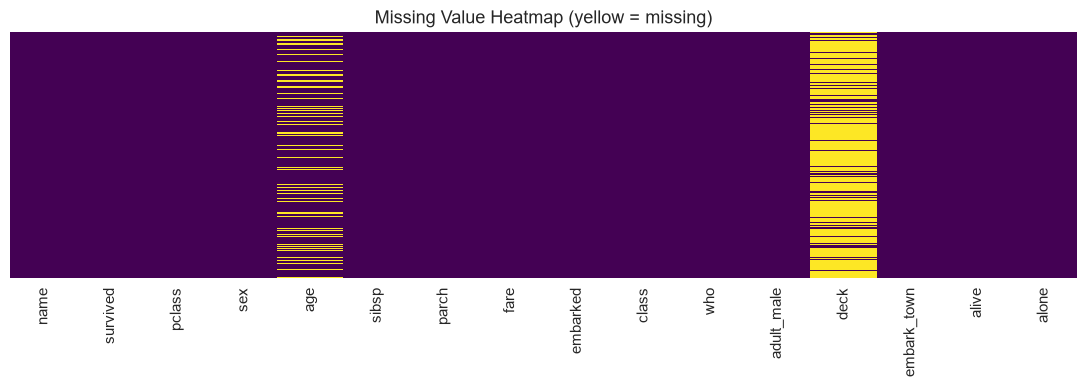

In [69]:
# Visualize missing-data pattern
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

### 9.2 Dropping missing values

In [70]:
# Drop rows with ANY missing value (rarely the right choice for wide DataFrames!)
print(f"Before: {df.shape}")
print(f"dropna(): {df.dropna().shape}")
# subset = only consider these columns when deciding what to drop
print(f"dropna(subset=['age']): {df.dropna(subset=['age']).shape}")
# thresh = require at least N non-null values
print(f"dropna(thresh=10): {df.dropna(thresh=10).shape}")

Before: (891, 16)
dropna(): (182, 16)
dropna(subset=['age']): (714, 16)
dropna(thresh=10): (891, 16)


### 9.3 Filling missing values

In [71]:
# Constant fill
df['age'].fillna(0).isna().sum()

np.int64(0)

In [72]:
# Mean/median imputation — the most common approach for numerics
df_filled = df.copy()
df_filled['age'] = df_filled['age'].fillna(df_filled['age'].median())
df_filled['age'].isna().sum()

np.int64(0)

In [73]:
# Mode for categoricals
df_filled['embarked'] = df_filled['embarked'].fillna(df_filled['embarked'].mode()[0])
df_filled['embarked'].isna().sum()

np.int64(0)

In [74]:
# Forward fill (use the last valid observation) — common in time series
s = pd.Series([1.0, np.nan, np.nan, 4.0, np.nan, 6.0])
print("Original:", s.tolist())
print("ffill:   ", s.ffill().tolist())
print("bfill:   ", s.bfill().tolist())

Original: [1.0, nan, nan, 4.0, nan, 6.0]
ffill:    [1.0, 1.0, 1.0, 4.0, 4.0, 6.0]
bfill:    [1.0, 4.0, 4.0, 4.0, 6.0, 6.0]


In [75]:
# Interpolation — best for ordered numerical data
s.interpolate().tolist()

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

> **Best practice:** when you impute, also create a flag column indicating which values were originally missing. This often becomes a useful feature for downstream models.

In [76]:
df_eng = df.copy()
df_eng['age_was_missing'] = df_eng['age'].isna().astype(int)
df_eng['age'] = df_eng['age'].fillna(df_eng['age'].median())
df_eng[['age', 'age_was_missing']].head()

,age,age_was_missing
0,22.0000,0
1,38.0000,0
2,26.0000,0
3,35.0000,0
4,35.0000,0


---
## 10. Data Types & Type Conversion

Each column has a single dtype. Choosing the right dtype affects **memory**, **speed**, and what **operations** are available.

### The main dtypes
| Dtype | Holds | Common use |
|-------|-------|-----------|
| `int64`, `int32`, `int16`, `int8` | integers | counts, IDs |
| `float64`, `float32` | floating-point | measurements, ratios |
| `bool` | True/False | flags |
| `object` | Python objects, usually strings | text |
| `category` | finite set of values | low-cardinality strings |
| `datetime64[ns]` | timestamps | dates and times |
| `timedelta64[ns]` | durations | elapsed time |

### 10.1 Converting types — `astype`

In [77]:
df_t = df.copy()
df_t['survived'] = df_t['survived'].astype('bool')
df_t['pclass'] = df_t['pclass'].astype('category')
df_t.dtypes

name                str
survived           bool
pclass         category
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

### 10.2 `pd.to_numeric` — convert strings to numbers safely

In [78]:
messy = pd.Series(['1', '2', '3', 'oops', '5'])
# errors='coerce' replaces bad values with NaN instead of raising
pd.to_numeric(messy, errors='coerce')

0   1.0000
1   2.0000
2   3.0000
3      NaN
4   5.0000
dtype: float64

### 10.3 `pd.to_datetime` — parse strings as dates

In [79]:
dates = pd.Series(['2024-01-15', '2024-02-20', '2024-03-25'])
parsed = pd.to_datetime(dates)
print(parsed)
print(parsed.dtype)

0   2024-01-15
1   2024-02-20
2   2024-03-25
dtype: datetime64[us]
datetime64[us]


### 10.4 Memory savings via dtype choice

In [80]:
# Same data, smaller memory
big = pd.Series(np.random.choice(['A', 'B', 'C', 'D'], size=100_000))
mem_obj = big.memory_usage(deep=True)
mem_cat = big.astype('category').memory_usage(deep=True)
print(f"object:   {mem_obj:>10,} bytes")
print(f"category: {mem_cat:>10,} bytes  ({mem_cat/mem_obj:.1%} of original)")

object:      900,132 bytes
category:    100,169 bytes  (11.1% of original)


---
## 11. String Operations — the `.str` accessor

Most string operations are accessed via `.str` on a Series. Every method is **vectorized** — applied to every element at once.

In [81]:
names = df['name'].head(10)
names

0           Brown, Mr. Henry
1     Martin, Miss. Margaret
2    Gordon, Miss. Catherine
3         Brown, Miss. Alice
4             Bird, Mr. John
5           Jones, Mr. Frank
6         O'Brien, Mr. Henry
7      Nelson, Master. Henry
8           Jones, Mrs. Mary
9      Quinn, Miss. Margaret
Name: name, dtype: str

In [82]:
names.str.lower().head(3)

0           brown, mr. henry
1     martin, miss. margaret
2    gordon, miss. catherine
Name: name, dtype: str

In [83]:
names.str.len().head(5)         # number of characters per name

0    16
1    22
2    23
3    18
4    14
Name: name, dtype: int64

In [84]:
# Extract titles like 'Mr.', 'Mrs.' from passenger names
df['title'] = df['name'].str.extract(r',\s*([^.]+)\.')
df['title'].value_counts().head(10)

title
Mr        537
Miss      228
Mrs        86
Master     40
Name: count, dtype: int64

In [85]:
# Split a string and grab one piece
df['name'].str.split(',').str[0].head()      # surname

0     Brown
1    Martin
2    Gordon
3     Brown
4      Bird
Name: name, dtype: object

In [86]:
# Boolean tests
df['name'].str.contains('Miss', case=False).sum()

np.int64(228)

In [87]:
# Strip whitespace, replace, etc.
sloppy = pd.Series(['  Apple ', '  banana', 'CHERRY  '])
sloppy.str.strip().str.title()

0     Apple
1    Banana
2    Cherry
dtype: str

---
## 12. DateTime Operations — the `.dt` accessor

When a column is `datetime64`, the `.dt` accessor exposes calendar components and date arithmetic.

In [88]:
# Generate a date range
dates = pd.date_range('2024-01-01', periods=10, freq='D')
ts = pd.DataFrame({'date': dates, 'value': np.random.randn(10).cumsum()})
ts

,date,value
0,2024-01-01,-0.3185
1,2024-01-02,-0.4219
2,2024-01-03,0.7836
3,2024-01-04,0.3263
4,2024-01-05,1.2224
5,2024-01-06,0.9486
6,2024-01-07,1.2490
7,2024-01-08,1.5909
8,2024-01-09,-0.1149
9,2024-01-10,-0.2488


In [89]:
# Component extraction
ts['year']      = ts['date'].dt.year
ts['month']     = ts['date'].dt.month
ts['day']       = ts['date'].dt.day
ts['dayofweek'] = ts['date'].dt.dayofweek    # Monday = 0
ts['day_name']  = ts['date'].dt.day_name()
ts.head()

,date,value,year,month,day,dayofweek,day_name
0,2024-01-01,-0.3185,2024,1,1,0,Monday
1,2024-01-02,-0.4219,2024,1,2,1,Tuesday
2,2024-01-03,0.7836,2024,1,3,2,Wednesday
3,2024-01-04,0.3263,2024,1,4,3,Thursday
4,2024-01-05,1.2224,2024,1,5,4,Friday


In [90]:
# Date arithmetic with Timedelta
ts['days_since_start'] = (ts['date'] - ts['date'].min()).dt.days
ts[['date', 'days_since_start']].head()

,date,days_since_start
0,2024-01-01,0
1,2024-01-02,1
2,2024-01-03,2
3,2024-01-04,3
4,2024-01-05,4


In [91]:
# date_range with different frequencies
pd.date_range('2024-01-01', periods=5, freq='W')    # weekly

DatetimeIndex(['2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28', '2024-02-04'], dtype='datetime64[us]', freq='W-SUN')

In [92]:
pd.date_range('2024-01-01', periods=5, freq='ME')   # month-end

DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31'], dtype='datetime64[us]', freq='ME')

---
## 13. `apply`, `map`, and `transform`

These methods let you apply custom Python functions to your data. Use them only when **vectorized** alternatives don't exist — they're slower than built-in pandas operations.

| Method | Where | Receives | Returns |
|--------|-------|----------|---------|
| `Series.map(f)` | Series | one scalar at a time | Series of same length |
| `Series.apply(f)` | Series | one scalar at a time | Series of same length |
| `DataFrame.apply(f, axis=0)` | DataFrame | one **column** | one value per column |
| `DataFrame.apply(f, axis=1)` | DataFrame | one **row** | one value per row |
| `DataFrame.applymap(f)` (now `.map`) | DataFrame | every cell | DataFrame of same shape |
| `transform(f)` | grouped | per group | same shape as input |

### 13.1 `Series.map` — element-wise transformation

In [93]:
# Most useful: dict-based mapping
df['sex_short'] = df['sex'].map({'male': 'M', 'female': 'F'})
df[['sex', 'sex_short']].head()

,sex,sex_short
0,male,M
1,female,F
2,female,F
3,female,F
4,male,M


In [94]:
# Or a function
df['age'].head().map(lambda x: 'adult' if x >= 18 else 'minor')

0    adult
1    adult
2    adult
3    adult
4    adult
Name: age, dtype: str

### 13.2 `DataFrame.apply` along an axis

In [95]:
# axis=0 (default): apply function to each COLUMN
df[['age', 'fare']].apply(lambda col: col.max() - col.min())

age     79.5800
fare   512.3292
dtype: float64

In [96]:
# axis=1: apply function to each ROW
df['family_size'] = df.apply(lambda row: row['sibsp'] + row['parch'] + 1, axis=1)
df[['sibsp', 'parch', 'family_size']].head()

# NOTE: For this specific case, df['sibsp'] + df['parch'] + 1 is far faster!
# Use apply(axis=1) only when no vectorized version exists.

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


---
## 14. GroupBy & Aggregation — The Workhorse

`groupby` is arguably the most important pandas feature. It implements the **split-apply-combine** pattern: split the data into groups, apply a function to each group, combine the results.

```
df.groupby('column')['target'].agg('mean')
       ↑                ↑       ↑
   split-by         column to   what to compute
                    summarize
```

### 14.1 Basic aggregation

In [97]:
# Survival rate by passenger class
df.groupby('pclass')['survived'].mean()

pclass
1   0.6296
2   0.4728
3   0.2424
Name: survived, dtype: float64

In [98]:
# Multiple statistics at once
df.groupby('pclass')['fare'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
pclass,,,,,,
1,84.1547,60.2875,78.3804,0.0000,512.3292,216
2,20.6622,14.2500,13.4174,0.0000,73.5000,184
3,13.6756,8.0500,11.7781,0.0000,69.5500,491


In [99]:
# Group by multiple columns
df.groupby(['pclass', 'sex'])['survived'].mean().unstack()

sex,female,male
pclass,,
1,0.9681,0.3689
2,0.9211,0.1574
3,0.5000,0.1354


### 14.2 Different aggregations per column

In [100]:
df.groupby('pclass').agg(
    mean_age=('age', 'mean'),
    median_fare=('fare', 'median'),
    survival_rate=('survived', 'mean'),
    n_passengers=('survived', 'count'),
)

,mean_age,median_fare,survival_rate,n_passengers
pclass,,,,
1,38.2334,60.2875,0.6296,216
2,29.8776,14.2500,0.4728,184
3,25.1406,8.0500,0.2424,491


### 14.3 `transform` — broadcast result back to original shape

Use `transform` when you want a per-group statistic attached to **every row** of that group.

In [101]:
# Add a column showing the AVERAGE fare paid by people in the same pclass
df['avg_fare_in_class'] = df.groupby('pclass')['fare'].transform('mean')
df[['pclass', 'fare', 'avg_fare_in_class']].head(8)

,pclass,fare,avg_fare_in_class
0,3,7.2500,13.6756
1,1,71.2833,84.1547
2,3,7.9250,13.6756
3,1,53.1000,84.1547
4,3,8.0500,13.6756
5,3,8.4583,13.6756
6,1,51.8625,84.1547
7,3,21.0750,13.6756


In [102]:
# Powerful pattern: compute deviation from group mean
df['fare_vs_group_avg'] = df['fare'] - df.groupby('pclass')['fare'].transform('mean')
df[['pclass', 'fare', 'fare_vs_group_avg']].head()

,pclass,fare,fare_vs_group_avg
0,3,7.2500,-6.4256
1,1,71.2833,-12.8714
2,3,7.9250,-5.7506
3,1,53.1000,-31.0547
4,3,8.0500,-5.6256


### 14.4 `filter` groups — keep entire groups based on a condition

In [103]:
# Keep only classes with more than 200 passengers
big_classes = df.groupby('pclass').filter(lambda g: len(g) > 200)
big_classes['pclass'].value_counts()

pclass
3    491
1    216
Name: count, dtype: int64

### 14.5 `pivot_table` — Excel-style cross-tabulation

In [104]:
pd.pivot_table(df, values='survived', index='pclass', columns='sex',
               aggfunc='mean', margins=True)

sex,female,male,All
pclass,,,
1,0.9681,0.3689,0.6296
2,0.9211,0.1574,0.4728
3,0.5000,0.1354,0.2424
All,0.7420,0.1889,0.3838


### 14.6 `crosstab` — frequency tables

In [105]:
pd.crosstab(df['pclass'], df['embarked'], margins=True)

embarked,C,Q,S,All
pclass,,,,
1,85,2,127,214
2,17,3,164,184
3,66,72,353,491
All,168,77,644,889


In [106]:
# Normalized as proportions
pd.crosstab(df['pclass'], df['embarked'], normalize='index').round(3)

embarked,C,Q,S
pclass,,,
1,0.3970,0.0090,0.5930
2,0.0920,0.0160,0.8910
3,0.1340,0.1470,0.7190


---
## 15. Joining, Merging & Concatenation

Real analyses combine multiple tables — customers + orders, students + grades, sensors + locations. Pandas offers three tools, each suited to a different shape of combination:

| Operation | Purpose | Think of it as |
|-----------|---------|----------------|
| `concat` | Stack DataFrames vertically or horizontally | "Glue these together" |
| `merge` | Join on shared columns / keys | "SQL JOIN" |
| `join` | Join on shared **index** | Shortcut for merge by index |

### 15.1 `concat` — stacking DataFrames

Use `concat` when both DataFrames have the **same columns** (vertical stack) or the **same index** (horizontal stack).

In [107]:
df_a = pd.DataFrame({'name': ['Alice', 'Bob'],   'age': [25, 30]})
df_b = pd.DataFrame({'name': ['Carol', 'Dan'],   'age': [35, 40]})

# Vertical stack (axis=0, the default)
pd.concat([df_a, df_b], ignore_index=True)

,name,age
0,Alice,25
1,Bob,30
2,Carol,35
3,Dan,40


In [192]:
# Horizontal stack (axis=1) — joins by index
df_left  = pd.DataFrame({'name': ['Alice', 'Bob', 'Carol']})
df_right = pd.DataFrame({'age': [25, 30, 35], 'city': ['Kathmandu', 'Pokhara', 'Lalitpur']})
pd.concat([df_left, df_right], axis=1)

,name,age,city
0,Alice,25,Kathmandu
1,Bob,30,Pokhara
2,Carol,35,Lalitpur


### 15.2 `merge` — SQL-style joins

`merge` is for combining DataFrames on shared **key columns**, just like an SQL JOIN.

**Four join types:**

| `how=` | What you keep |
|--------|---------------|
| `'inner'` (default) | Only keys present in BOTH tables |
| `'left'` | All keys from left, matching from right |
| `'right'` | All keys from right, matching from left |
| `'outer'` | All keys from either table — NaN where missing |

In [109]:
customers = pd.DataFrame({
    'cust_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Carol', 'Dan']
})
orders = pd.DataFrame({
    'cust_id': [1, 1, 2, 5],
    'product': ['Book', 'Pen', 'Laptop', 'Phone'],
    'amount': [15, 5, 1200, 800]
})

print("Inner join — only customers WITH orders, only orders WITH a customer:")
pd.merge(customers, orders, on='cust_id', how='inner')

Inner join — only customers WITH orders, only orders WITH a customer:


,cust_id,name,product,amount
0,1,Alice,Book,15
1,1,Alice,Pen,5
2,2,Bob,Laptop,1200


In [110]:
print("Left join — all customers, even those without orders:")
pd.merge(customers, orders, on='cust_id', how='left')

Left join — all customers, even those without orders:


,cust_id,name,product,amount
0,1,Alice,Book,15.0000
1,1,Alice,Pen,5.0000
2,2,Bob,Laptop,1200.0000
3,3,Carol,NaN,NaN
4,4,Dan,NaN,NaN


In [111]:
print("Outer join — everything from both sides:")
pd.merge(customers, orders, on='cust_id', how='outer')

Outer join — everything from both sides:


,cust_id,name,product,amount
0,1,Alice,Book,15.0000
1,1,Alice,Pen,5.0000
2,2,Bob,Laptop,1200.0000
3,3,Carol,NaN,NaN
4,4,Dan,NaN,NaN
5,5,NaN,Phone,800.0000


### 15.3 Merging on differently-named columns

In [112]:
left = pd.DataFrame({'id': [1, 2, 3], 'name': ['A', 'B', 'C']})
right = pd.DataFrame({'user_id': [1, 2, 4], 'score': [90, 85, 70]})
pd.merge(left, right, left_on='id', right_on='user_id', how='left')

,id,name,user_id,score
0,1,A,1.0000,90.0000
1,2,B,2.0000,85.0000
2,3,C,NaN,NaN


### 15.4 Indicator column — diagnose join coverage

When debugging a merge, the `indicator=True` flag adds a `_merge` column showing where each row came from.

In [113]:
result = pd.merge(customers, orders, on='cust_id', how='outer', indicator=True)
result['_merge'].value_counts()

_merge
both          3
left_only     2
right_only    1
Name: count, dtype: int64

---
## 16. Reshaping Data

Real data comes in two flavors:

- **Wide format**: each row is one entity, each variable is its own column
- **Long format**: each row is one observation (entity + variable + value)

You'll need to convert between them constantly. The four core methods:

| From | To | Method |
|------|----|----|
| Long → Wide | `pivot` or `pivot_table` |
| Wide → Long | `melt` |
| Move column → index level | `set_index` then `stack` |
| Move index level → column | `unstack` |

### 16.1 Wide vs. long — see them side by side

In [114]:
wide = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol'],
    'math':    [90, 80, 95],
    'physics': [85, 75, 88],
    'biology': [92, 78, 91],
})
print("WIDE format:")
print(wide)

WIDE format:
  student  math  physics  biology
0   Alice    90       85       92
1     Bob    80       75       78
2   Carol    95       88       91


In [115]:
long = wide.melt(id_vars='student', var_name='subject', value_name='score')
print("LONG format:")
print(long)

LONG format:
  student  subject  score
0   Alice     math     90
1     Bob     math     80
2   Carol     math     95
3   Alice  physics     85
4     Bob  physics     75
5   Carol  physics     88
6   Alice  biology     92
7     Bob  biology     78
8   Carol  biology     91


### 16.2 `pivot_table` — long to wide (with aggregation)

In [116]:
# Back from long → wide
long.pivot_table(index='student', columns='subject', values='score')

subject,biology,math,physics
student,,,
Alice,92.0000,90.0000,85.0000
Bob,78.0000,80.0000,75.0000
Carol,91.0000,95.0000,88.0000


### 16.3 `stack` and `unstack`

These two methods move data between the columns and the index. `stack` pivots columns down into rows; `unstack` does the reverse.

In [117]:
df = load_titanic()
table = df.groupby(['pclass', 'sex'])['survived'].mean()
print(table)

pclass  sex   
1       female   0.9681
        male     0.3689
2       female   0.9211
        male     0.1574
3       female   0.5000
        male     0.1354
Name: survived, dtype: float64


In [118]:
# unstack the last index level into columns
table.unstack()

sex,female,male
pclass,,
1,0.9681,0.3689
2,0.9211,0.1574
3,0.5000,0.1354


### 16.4 `explode` — one row per item in a list column

In [119]:
df_list = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol'],
    'subjects': [['math', 'physics'], ['biology'], ['math', 'biology', 'physics']]
})
df_list.explode('subjects')

,student,subjects
0,Alice,math
0,Alice,physics
1,Bob,biology
2,Carol,math
2,Carol,biology
2,Carol,physics


---
## 17. Sorting & Ranking

In [120]:
df = load_titanic()
# Sort by one column
df.sort_values(by='age', ascending=False).head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,"Carter, Mr. Frank",1,1,male,80.0000,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
851,"Nelson, Mr. William",0,3,male,74.0000,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
493,"Lewis, Mr. James",0,1,male,71.0000,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
96,"Lewis, Mr. James",0,1,male,71.0000,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,"Smith, Mr. Henry",0,3,male,70.5000,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


In [195]:
# Sort by multiple columns — second column breaks ties
df.sort_values(by=['pclass', 'fare'], ascending=[True, False]).head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
258,"Roberts, Miss. Mary",1,1,female,35.0000,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
679,"Allen, Mr. James",1,1,male,36.0000,0,1,512.3292,C,First,man,True,B,Cherbourg,yes,False
737,"Taylor, Mr. James",1,1,male,35.0000,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True
27,"Harris, Mr. John",0,1,male,19.0000,3,2,263.0000,S,First,man,True,C,Southampton,no,False
88,"Nelson, Mrs. Anna",1,1,female,23.0000,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False


In [122]:
# Where do NaN values go?
df.sort_values('age', na_position='first').head()

,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,"Jones, Mr. Frank",0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
17,"Roberts, Mr. John",1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
19,"Davies, Miss. Alice",1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
26,"Fitzgerald, Mr. George",0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,"Kelly, Miss. Anna",1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True


### 17.1 Ranking — assign a rank to each value

In [123]:
s = pd.Series([85, 92, 78, 92, 65, 88])
ranks = pd.DataFrame({
    'value': s,
    'rank_average': s.rank(),                    # ties → average rank
    'rank_min':     s.rank(method='min'),        # ties → min rank in group
    'rank_dense':   s.rank(method='dense'),      # ties → same rank, no gaps
    'rank_first':   s.rank(method='first'),      # ties → broken by order in data
})
ranks

,value,rank_average,rank_min,rank_dense,rank_first
0,85,3.0000,3.0000,3.0000,3.0000
1,92,5.5000,5.0000,5.0000,5.0000
2,78,2.0000,2.0000,2.0000,2.0000
3,92,5.5000,5.0000,5.0000,6.0000
4,65,1.0000,1.0000,1.0000,1.0000
5,88,4.0000,4.0000,4.0000,4.0000


---
## 18. Window Functions & Rolling Statistics

A **window function** computes a statistic over a sliding window of observations. Essential for time series and trend analysis.

| Method | What it does |
|--------|--------------|
| `rolling(window=N)` | Sliding window of size N |
| `expanding()` | All observations up to current point |
| `ewm(span=N)` | Exponentially-weighted moving stats |
| `shift(N)` | Shift values by N positions (lag/lead) |
| `diff()` | First difference (current − previous) |
| `pct_change()` | Percent change vs. previous |
| `cumsum`, `cumprod`, `cummax`, `cummin` | Cumulative versions |

In [124]:
# Simulate a time series
ts = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=30),
    'sales': (100 + np.random.randn(30).cumsum() * 10).round(2)
})
ts.head()

,date,sales
0,2024-01-01,106.8200
1,2024-01-02,97.6800
2,2024-01-03,90.2000
3,2024-01-04,94.8700
4,2024-01-05,106.7700


In [125]:
# 7-day rolling mean (smoothes noisy data)
ts['rolling_mean_7']   = ts['sales'].rolling(window=7).mean()
ts['rolling_std_7']    = ts['sales'].rolling(window=7).std()
ts['expanding_mean']   = ts['sales'].expanding().mean()
ts['lag_1']            = ts['sales'].shift(1)
ts['daily_change']     = ts['sales'].diff()
ts['pct_change']       = ts['sales'].pct_change() * 100
ts.head(10).round(2)

,date,sales,rolling_mean_7,rolling_std_7,expanding_mean,lag_1,daily_change,pct_change
0,2024-01-01,106.8200,NaN,NaN,106.8200,NaN,NaN,NaN
1,2024-01-02,97.6800,NaN,NaN,102.2500,106.8200,-9.1400,-8.5600
2,2024-01-03,90.2000,NaN,NaN,98.2300,97.6800,-7.4800,-7.6600
3,2024-01-04,94.8700,NaN,NaN,97.3900,90.2000,4.6700,5.1800
4,2024-01-05,106.7700,NaN,NaN,99.2700,94.8700,11.9000,12.5400
5,2024-01-06,97.5600,NaN,NaN,98.9800,106.7700,-9.2100,-8.6300
6,2024-01-07,93.8900,98.2600,6.3500,98.2600,97.5600,-3.6700,-3.7600
7,2024-01-08,106.3600,98.1900,6.2500,99.2700,93.8900,12.4700,13.2800
8,2024-01-09,98.0500,98.2400,6.2500,99.1300,106.3600,-8.3100,-7.8100
9,2024-01-10,111.5500,101.2900,6.8500,100.3800,98.0500,13.5000,13.7700


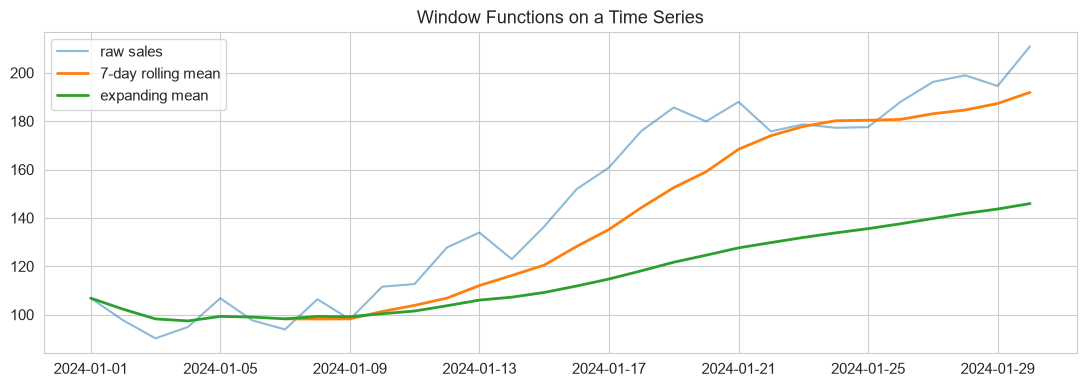

In [126]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts['date'], ts['sales'], label='raw sales', alpha=0.5)
ax.plot(ts['date'], ts['rolling_mean_7'], label='7-day rolling mean', linewidth=2)
ax.plot(ts['date'], ts['expanding_mean'], label='expanding mean', linewidth=2)
ax.set_title('Window Functions on a Time Series')
ax.legend()
plt.tight_layout()
plt.show()

---
## 19. Time Series Operations

When the index is a `DatetimeIndex`, pandas unlocks specialized time-aware operations.

In [127]:
ts = pd.DataFrame({
    'value': np.random.randn(365).cumsum() + 100
}, index=pd.date_range('2024-01-01', periods=365))
ts.head()

,value
2024-01-01,100.4916
2024-01-02,99.1868
2024-01-03,98.6228
2024-01-04,97.6491
2024-01-05,97.6065


### 19.1 Slicing by date (when the index is datetime)

In [128]:
ts.loc['2024-03'].head()       # all of March 2024

,value
2024-03-01,86.0653
2024-03-02,85.7007
2024-03-03,85.6896
2024-03-04,85.9825
2024-03-05,84.5571


In [129]:
ts.loc['2024-03':'2024-04'].shape    # March through April

(61, 1)

### 19.2 `resample` — change the time frequency

Resampling is groupby for time. Group all observations falling in each week / month / quarter and aggregate.

In [130]:
monthly = ts.resample('ME').agg(['mean', 'min', 'max'])
monthly.head()

value                 
              mean     min      max
2024-01-31 95.2438 89.4326 100.4916
2024-02-29 87.7012 83.4878  91.8702
2024-03-31 84.9214 81.7786  87.0565
2024-04-30 84.8532 81.6743  88.0199
2024-05-31 84.5849 82.2830  86.6959

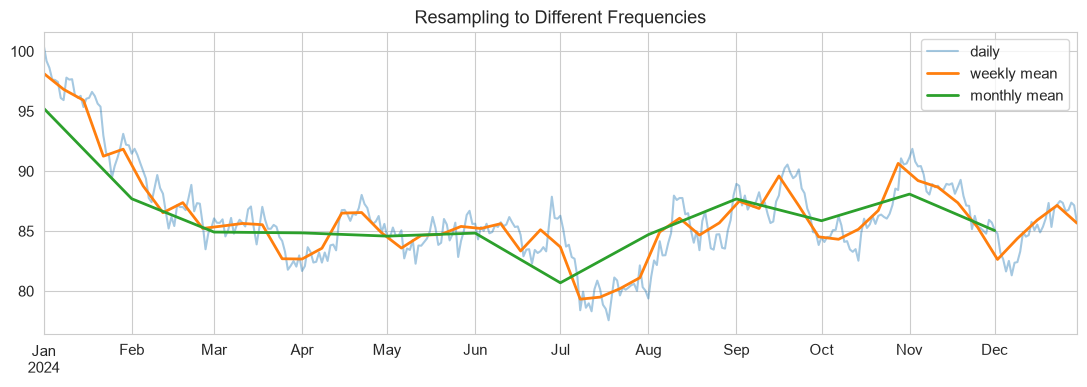

In [131]:
fig, ax = plt.subplots(figsize=(11, 4))
ts['value'].plot(ax=ax, alpha=0.4, label='daily')
ts['value'].resample('W').mean().plot(ax=ax, label='weekly mean', linewidth=2)
ts['value'].resample('ME').mean().plot(ax=ax, label='monthly mean', linewidth=2)
ax.legend(); ax.set_title('Resampling to Different Frequencies')
plt.tight_layout(); plt.show()

---
## 20. Categorical Data

For columns with a **small fixed set of values** (gender, country, education level), the `category` dtype is far more memory-efficient than `object` and unlocks ordered comparisons.

In [132]:
df = load_titanic()
df['class'] = df['class'].astype('category')
df['class'].cat.categories

Index(['First', 'Second', 'Third'], dtype='str')

In [133]:
# Define an ORDERED category (so comparisons make sense)
df['class'] = df['class'].cat.set_categories(['Third', 'Second', 'First'], ordered=True)
# Now we can compare
(df['class'] > 'Second').sum()

np.int64(216)

### `get_dummies` — one-hot encoding

In [134]:
pd.get_dummies(df['embarked'], prefix='embarked').head()

,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


---
## 21. Performance & Memory Tips

A short tour of what makes pandas code fast or slow.

### 1. Vectorize, don't loop

In [135]:
import time
df = load_titanic()

# SLOW — Python-level loop
start = time.time()
result_slow = []
for _, row in df.iterrows():
    result_slow.append(row['age'] * 2 if pd.notna(row['age']) else None)
t_slow = time.time() - start

# FAST — vectorized
start = time.time()
result_fast = df['age'] * 2
t_fast = time.time() - start

print(f"iterrows loop : {t_slow*1000:7.2f} ms")
print(f"vectorized    : {t_fast*1000:7.2f} ms")
print(f"speedup       : {t_slow/t_fast:.0f}x")

iterrows loop :   13.94 ms
vectorized    :    0.25 ms
speedup       : 55x


### 2. Use the right dtypes

We saw earlier that `category` cuts memory dramatically for low-cardinality strings. Likewise, an `int8` (4 bytes) is half the memory of an `int16`, a quarter of an `int32`, and an eighth of an `int64`. For columns where you know the range, downcasting helps.

In [136]:
df_big = pd.DataFrame({'small_ints': np.random.randint(0, 100, 100_000)})
print(f"int64 default : {df_big.memory_usage(deep=True).sum():,} bytes")
df_big['small_ints'] = df_big['small_ints'].astype('int8')
print(f"int8 downcast : {df_big.memory_usage(deep=True).sum():,} bytes")

int64 default : 400,132 bytes
int8 downcast : 100,132 bytes


### 3. Avoid chained assignment — use `.loc`

In [137]:
# BAD — may raise SettingWithCopyWarning and may not actually modify
# df[df['age'] > 30]['fare'] = 0

# GOOD
df.loc[df['age'] > 30, 'fare'] = df.loc[df['age'] > 30, 'fare']  # in-place safe

### 4. `eval` and `query` for big DataFrames

For huge DataFrames, `eval` and `query` can be faster because they avoid creating intermediate objects.

In [138]:
df = load_titanic()
# Equivalent results
a = df[(df['age'] > 30) & (df['fare'] > 50)]
b = df.query('age > 30 and fare > 50')
print(a.shape == b.shape)

True


---
---
# 📐 PART III — Statistics & Probability

The pandas knowledge above gets your data into shape. **Statistics** is what you do with it once it's clean.

This part covers the full body of statistical and probabilistic ideas a working data scientist relies on, with every concept demonstrated on the Titanic dataset using pandas and scipy.

> **A note on philosophy:** statistics is not memorizing formulas. It's about asking *what does my data actually mean, and how confident can I be in any conclusion I draw?* Every method below answers a version of that question.

---
## 22. Descriptive Statistics

**Descriptive statistics** summarize the basic features of a dataset — its center, spread, and shape. They are the first numbers you compute, every single time, on every single dataset.

The three families of descriptive statistics:

| Family | What it tells you | Typical measures |
|--------|-------------------|------------------|
| **Central tendency** | Where the "middle" is | Mean, median, mode |
| **Dispersion** | How spread out values are | Variance, std dev, range, IQR |
| **Shape** | How the distribution is shaped | Skewness, kurtosis |

### 22.1 Measures of Central Tendency

| Measure | Definition | When to use |
|---------|-----------|-------------|
| **Mean** | Arithmetic average | Symmetric distributions, no extreme outliers |
| **Median** | The middle value when sorted | Skewed data, presence of outliers |
| **Mode** | The most frequent value | Categorical data |

**The mean-median test for skewness:**
- Mean > Median → distribution is **right-skewed** (tail to the right)
- Mean < Median → distribution is **left-skewed** (tail to the left)
- Mean ≈ Median → distribution is roughly symmetric

In [139]:
df = load_titanic()

print("AGE (roughly symmetric):")
print(f"  mean   = {df['age'].mean():.2f}")
print(f"  median = {df['age'].median():.2f}")
print(f"  mode   = {df['age'].mode()[0]:.2f}")
print()
print("FARE (heavily right-skewed):")
print(f"  mean   = {df['fare'].mean():.2f}")
print(f"  median = {df['fare'].median():.2f}")
print(f"  mode   = {df['fare'].mode()[0]:.2f}")
print()
print("→ For fare, the mean (32.20) is over 2× the median (14.45) — a few rich passengers pulled the average way up.")

AGE (roughly symmetric):
  mean   = 29.70
  median = 28.00
  mode   = 24.00

FARE (heavily right-skewed):
  mean   = 32.20
  median = 14.45
  mode   = 8.05

→ For fare, the mean (32.20) is over 2× the median (14.45) — a few rich passengers pulled the average way up.


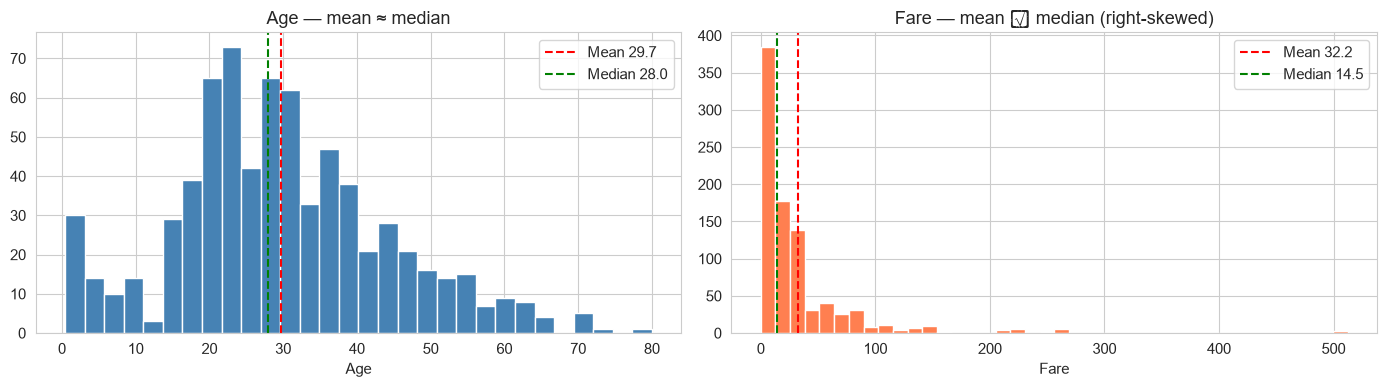

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', label=f'Median {df["age"].median():.1f}')
axes[0].set_title('Age — mean ≈ median'); axes[0].legend(); axes[0].set_xlabel('Age')

axes[1].hist(df['fare'], bins=40, color='coral', edgecolor='white')
axes[1].axvline(df['fare'].mean(), color='red', linestyle='--', label=f'Mean {df["fare"].mean():.1f}')
axes[1].axvline(df['fare'].median(), color='green', linestyle='--', label=f'Median {df["fare"].median():.1f}')
axes[1].set_title('Fare — mean ≫ median (right-skewed)'); axes[1].legend(); axes[1].set_xlabel('Fare')

plt.tight_layout(); plt.show()

### 22.2 Measures of Dispersion (Spread)

These tell you **how much the data varies** around its center. Two datasets can have identical means but completely different spreads.

| Measure | Definition |
|---------|-----------|
| **Range** | max − min |
| **Variance** | average squared deviation from the mean |
| **Std deviation** | √variance — same units as the data |
| **IQR** | Q3 − Q1 (interquartile range, middle 50%) |
| **MAD** | mean absolute deviation |

**Variance & standard deviation:** the most common measures. Standard deviation is preferred because it's in the same units as the data (variance is in **squared** units).

**Population vs. sample:** when computing variance/std from a *sample* of data (which is almost always the case), we divide by `n-1`, not `n`. This is **Bessel's correction**, and pandas uses it by default (`ddof=1`).

In [141]:
print("FARE dispersion:")
print(f"  range   = {df['fare'].max() - df['fare'].min():.2f}")
print(f"  var     = {df['fare'].var():.2f}")
print(f"  std     = {df['fare'].std():.2f}")
print(f"  IQR     = {df['fare'].quantile(0.75) - df['fare'].quantile(0.25):.2f}")
print(f"  MAD     = {(df['fare'] - df['fare'].mean()).abs().mean():.2f}")

FARE dispersion:
  range   = 512.33
  var     = 2469.44
  std     = 49.69
  IQR     = 23.09
  MAD     = 28.16


### 22.3 Quantiles, Percentiles, and the Five-Number Summary

A **quantile** at value q (0 ≤ q ≤ 1) divides the data so that q proportion of values lie below it. Percentiles are quantiles expressed as percentages.

- **Q1** = 25th percentile (0.25 quantile)
- **Median** = 50th percentile (0.50 quantile)
- **Q3** = 75th percentile (0.75 quantile)

In [142]:
df['fare'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.1000     7.5500
0.2500     7.9104
0.5000    14.4542
0.7500    31.0000
0.9000    77.9583
0.9500   112.0791
0.9900   249.0062
Name: fare, dtype: float64

In [143]:
# Five-number summary
print(df['fare'].describe())

count   891.0000
mean     32.2042
std      49.6934
min       0.0000
25%       7.9104
50%      14.4542
75%      31.0000
max     512.3292
Name: fare, dtype: float64


### 22.4 Measures of Shape — Skewness & Kurtosis

These describe the **shape** of the distribution beyond center and spread.

| Statistic | What it measures |
|-----------|------------------|
| **Skewness** | Asymmetry of the distribution |
| **Kurtosis** | "Tailedness" — how much weight is in the tails |

**Skewness interpretation:**
- ≈ 0 → symmetric
- \> 0 → right-skewed (long right tail; mean > median)
- < 0 → left-skewed (long left tail; mean < median)

**Kurtosis interpretation (excess kurtosis, normal = 0):**
- ≈ 0 → "normal" tails (mesokurtic)
- \> 0 → heavy tails, more outliers (leptokurtic)
- < 0 → light tails, few outliers (platykurtic)

In [144]:
for col in ['age', 'fare']:
    print(f"{col:8s} : skew = {df[col].skew():+.2f},  kurtosis = {df[col].kurtosis():+.2f}")

age      : skew = +0.39,  kurtosis = +0.18
fare     : skew = +4.79,  kurtosis = +33.40


**Reading the numbers:**
- Age: skew ≈ 0.4 (mildly right-skewed), kurtosis ≈ 0.2 (close to normal)
- Fare: skew ≈ 4.8 (extremely right-skewed!), kurtosis ≈ 33 (very heavy tail)

The fare values are essentially what you'd expect for an income-like variable.

### 22.5 The All-in-One Summary

In [145]:
def descriptive_summary(s, name=None):
    name = name or s.name
    return pd.Series({
        'count':    s.count(),
        'missing':  s.isna().sum(),
        'mean':     s.mean(),
        'median':   s.median(),
        'mode':     s.mode().iloc[0] if not s.mode().empty else np.nan,
        'std':      s.std(),
        'var':      s.var(),
        'min':      s.min(),
        'Q1':       s.quantile(0.25),
        'Q3':       s.quantile(0.75),
        'IQR':      s.quantile(0.75) - s.quantile(0.25),
        'max':      s.max(),
        'range':    s.max() - s.min(),
        'skew':     s.skew(),
        'kurtosis': s.kurtosis(),
    }, name=name)

pd.DataFrame({
    'age':  descriptive_summary(df['age']),
    'fare': descriptive_summary(df['fare']),
}).round(3)

,age,fare
count,714.0000,891.0000
missing,177.0000,0.0000
mean,29.6990,32.2040
median,28.0000,14.4540
mode,24.0000,8.0500
std,14.5260,49.6930
var,211.0190,2469.4370
min,0.4200,0.0000
Q1,20.1250,7.9100
Q3,38.0000,31.0000


---
## 23. Probability Distributions

A **probability distribution** describes how the values of a random variable are distributed — what values are possible, and how likely each is.

### Two big families

| Type | Variable | Example |
|------|----------|---------|
| **Discrete** | Countable outcomes (integers) | # heads in 10 coin flips |
| **Continuous** | Uncountable outcomes (real numbers) | a person's height |

For discrete variables we use a **PMF** (probability mass function): P(X = x).
For continuous variables we use a **PDF** (probability density function): density at x.

The **CDF** (cumulative distribution function) F(x) = P(X ≤ x) works for both.

### 23.1 The Normal (Gaussian) Distribution

The single most important continuous distribution. Parameterized by mean **μ** and standard deviation **σ**.

**Why it matters:**
- Many natural phenomena follow it (heights, measurement errors)
- The **Central Limit Theorem** says sample means tend toward normal regardless of the source distribution
- Most statistical tests assume normality

**The 68-95-99.7 rule:**
- ~68% of values fall within ±1σ of the mean
- ~95% within ±2σ
- ~99.7% within ±3σ

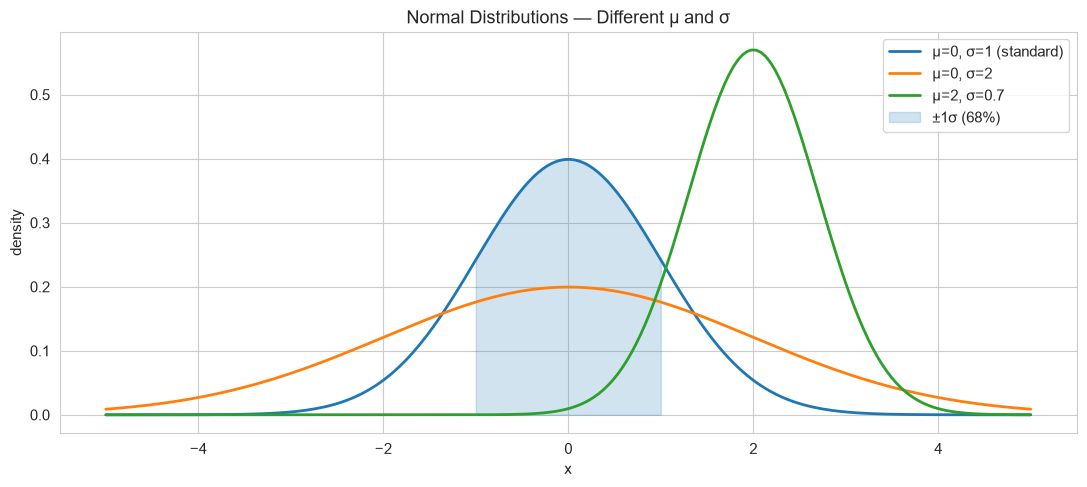

In [146]:
from scipy import stats

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(11, 5))

for mu, sigma, label in [(0, 1, 'μ=0, σ=1 (standard)'),
                          (0, 2, 'μ=0, σ=2'),
                          (2, 0.7, 'μ=2, σ=0.7')]:
    ax.plot(x, stats.norm.pdf(x, mu, sigma), label=label, linewidth=2)

# Shade the 68% region for the standard normal
xs = np.linspace(-1, 1, 50)
ax.fill_between(xs, stats.norm.pdf(xs, 0, 1), alpha=0.2, color='C0', label='±1σ (68%)')

ax.set_title('Normal Distributions — Different μ and σ')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('density')
plt.tight_layout(); plt.show()

### 23.2 The Uniform Distribution

All outcomes in a range are equally likely. Used in random number generation, simulation, and as a baseline ("if there were no preference").

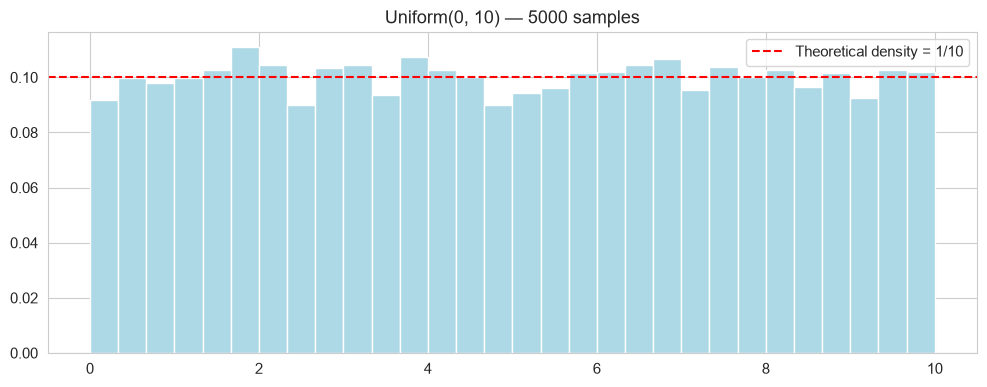

In [147]:
samples = np.random.uniform(0, 10, 5000)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples, bins=30, density=True, color='lightblue', edgecolor='white')
ax.axhline(0.1, color='red', linestyle='--', label='Theoretical density = 1/10')
ax.set_title('Uniform(0, 10) — 5000 samples')
ax.legend(); plt.tight_layout(); plt.show()

### 23.3 The Binomial Distribution (Discrete)

Number of **successes** in n independent trials, each with success probability p. Parameters: n, p.

**Use cases:**
- # of heads in 100 coin flips
- # of customers who click an ad out of 1000 shown
- # of survivors in a group of 50 passengers

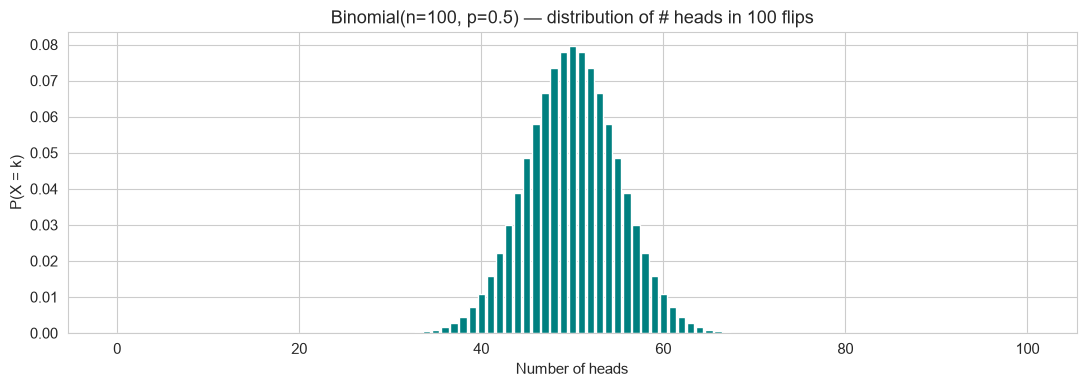

Titanic: 342/891 survived → P(survive) ≈ 0.384


In [148]:
n, p = 100, 0.5
k = np.arange(0, n+1)
pmf = stats.binom.pmf(k, n, p)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(k, pmf, color='teal', edgecolor='white')
ax.set_title(f'Binomial(n={n}, p={p}) — distribution of # heads in 100 flips')
ax.set_xlabel('Number of heads'); ax.set_ylabel('P(X = k)')
plt.tight_layout(); plt.show()

# Use the Titanic to verify the binomial idea
survived = df['survived'].sum()
total = len(df)
print(f"Titanic: {survived}/{total} survived → P(survive) ≈ {survived/total:.3f}")

### 23.4 The Poisson Distribution (Discrete)

Number of events occurring in a fixed interval, when events happen at a constant average rate λ independently of each other.

**Use cases:**
- # of customers arriving per hour
- # of emails received per day
- # of typos per page

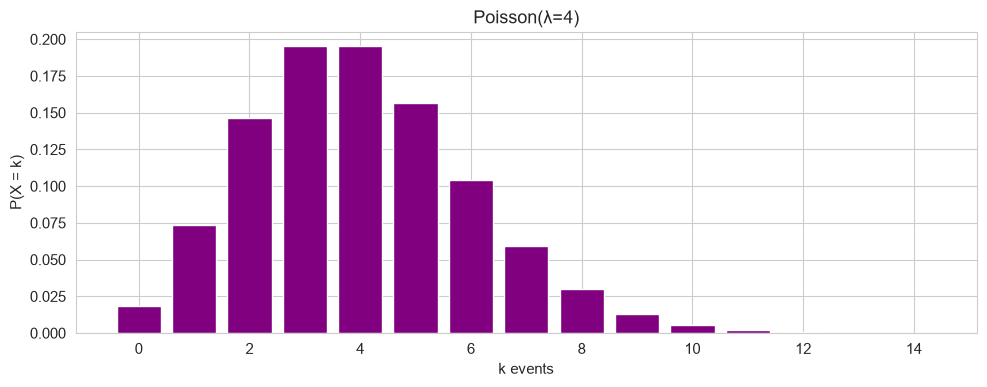

In [149]:
lam = 4
k = np.arange(0, 15)
pmf = stats.poisson.pmf(k, lam)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(k, pmf, color='purple', edgecolor='white')
ax.set_title(f'Poisson(λ={lam})')
ax.set_xlabel('k events'); ax.set_ylabel('P(X = k)')
plt.tight_layout(); plt.show()

### 23.5 The Exponential Distribution (Continuous)

Models the **time between events** in a Poisson process. Memoryless: the future doesn't depend on the past.

**Use cases:**
- Time until next earthquake
- Time between customer arrivals
- Lifetime of an electronic component

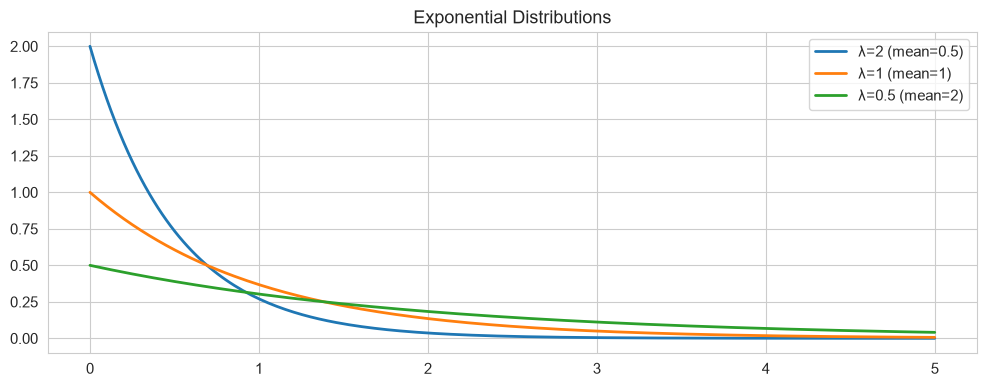

In [150]:
x = np.linspace(0, 5, 200)
fig, ax = plt.subplots(figsize=(10, 4))
for scale, lbl in [(0.5, 'λ=2 (mean=0.5)'), (1, 'λ=1 (mean=1)'), (2, 'λ=0.5 (mean=2)')]:
    ax.plot(x, stats.expon.pdf(x, scale=scale), label=lbl, linewidth=2)
ax.set_title('Exponential Distributions')
ax.legend(); plt.tight_layout(); plt.show()

### 23.6 Checking if Real Data Follows a Distribution

When you suspect your data is normal (or any other distribution), three tools help you verify:

1. **Histogram + theoretical density overlay**
2. **Q-Q plot** (quantile-quantile): if the points lie on the diagonal, the data matches
3. **Statistical normality tests**: Shapiro–Wilk, Kolmogorov–Smirnov, D'Agostino

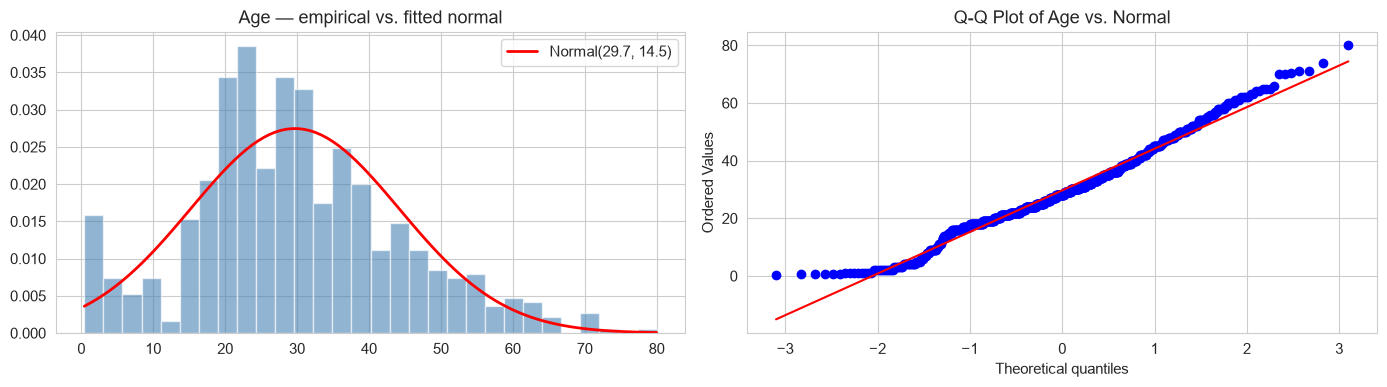

In [151]:
ages = df['age'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram with fitted normal
axes[0].hist(ages, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
mu, sigma = ages.mean(), ages.std()
x = np.linspace(ages.min(), ages.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal({mu:.1f}, {sigma:.1f})')
axes[0].set_title('Age — empirical vs. fitted normal')
axes[0].legend()

# Q-Q plot
stats.probplot(ages, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Age vs. Normal')

plt.tight_layout(); plt.show()

In [152]:
# Statistical normality tests
shapiro_stat, shapiro_p = stats.shapiro(ages.sample(500, random_state=0))
ks_stat, ks_p = stats.kstest(ages, lambda x: stats.norm.cdf(x, ages.mean(), ages.std()))

print(f"Shapiro–Wilk : statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(f"K–S          : statistic={ks_stat:.4f}, p-value={ks_p:.4f}")
print()
print("If p < 0.05 → reject the null hypothesis that the data is normal.")
print("With this many points, even small deviations from normality produce p < 0.05.")

Shapiro–Wilk : statistic=0.9796, p-value=0.0000
K–S          : statistic=0.0646, p-value=0.0050

If p < 0.05 → reject the null hypothesis that the data is normal.
With this many points, even small deviations from normality produce p < 0.05.


---
## 24. Probability Concepts — Joint, Marginal, Conditional

The three core probability ideas you'll use to reason about data. We can compute every one of them from a frequency table.

| Concept | Notation | Means |
|---------|----------|-------|
| **Joint** | P(A and B) | Probability that **both** A and B happen |
| **Marginal** | P(A) | Probability of A, irrespective of B |
| **Conditional** | P(A \| B) | Probability of A **given that** B happened |

The fundamental link:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

For Titanic, A could be "survived" and B could be "female". P(survived | female) is the survival rate among women.

### 24.1 Joint probabilities — a contingency table

In [153]:
# Joint frequency table
joint_counts = pd.crosstab(df['sex'], df['survived'])
print("Joint COUNTS:")
print(joint_counts)
print()

joint = pd.crosstab(df['sex'], df['survived'], normalize='all')
print("\nJoint PROBABILITIES P(sex AND survived):")
print(joint.round(3))

Joint COUNTS:
survived    0    1
sex               
female     81  233
male      468  109


Joint PROBABILITIES P(sex AND survived):
survived      0      1
sex                   
female   0.0910 0.2620
male     0.5250 0.1220


### 24.2 Marginal probabilities — sum across rows or columns

In [154]:
print("Marginal P(sex):")
print(joint.sum(axis=1).round(3))
print("\nMarginal P(survived):")
print(joint.sum(axis=0).round(3))

Marginal P(sex):
sex
female   0.3520
male     0.6480
dtype: float64

Marginal P(survived):
survived
0   0.6160
1   0.3840
dtype: float64


### 24.3 Conditional probabilities — `normalize='index'` or `'columns'`

In [155]:
# P(survived | sex)  — survival rate within each sex
cond_surv_given_sex = pd.crosstab(df['sex'], df['survived'], normalize='index')
print("P(survived | sex):")
print(cond_surv_given_sex.round(3))
print()
print("→ A female passenger had a 74% chance of survival; a male, just 19%.")

P(survived | sex):
survived      0      1
sex                   
female   0.2580 0.7420
male     0.8110 0.1890

→ A female passenger had a 74% chance of survival; a male, just 19%.


In [156]:
# P(sex | survived) — among survivors, what was the sex distribution?
cond_sex_given_surv = pd.crosstab(df['sex'], df['survived'], normalize='columns')
print("P(sex | survived):")
print(cond_sex_given_surv.round(3))
print()
print("→ Among survivors, 68% were female. Among non-survivors, only 15% were female.")

P(sex | survived):
survived      0      1
sex                   
female   0.1480 0.6810
male     0.8520 0.3190

→ Among survivors, 68% were female. Among non-survivors, only 15% were female.


### 24.4 Bayes' Theorem in pandas

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

Bayes' theorem lets you **flip a conditional probability**. We saw P(survived | female) = 0.74. Suppose we want P(female | survived) — the probability that a random survivor is female.

In [157]:
# Using Bayes:  P(female | survived) = P(survived | female) * P(female) / P(survived)
p_surv_given_female = 0.742       # from the table above
p_female            = df['sex'].value_counts(normalize=True)['female']
p_survived          = df['survived'].mean()

p_female_given_surv = p_surv_given_female * p_female / p_survived
print(f"P(female | survived) by Bayes  = {p_female_given_surv:.3f}")
print(f"P(female | survived) by table  = {cond_sex_given_surv.loc['female', 1]:.3f}")

P(female | survived) by Bayes  = 0.681
P(female | survived) by table  = 0.681


### 24.5 Independence — when does P(A|B) = P(A)?

Two events are **independent** when knowing one tells you nothing about the other:

$$ P(A \mid B) = P(A) \iff P(A \cap B) = P(A) \cdot P(B) $$

If P(survived | female) = P(survived), then sex and survival would be independent. We saw P(survived | female) = 0.74 vs. marginal P(survived) = 0.38 — these are **very** different, so sex and survival are clearly NOT independent. The Chi-square test (Section 27) makes this rigorous.

---
## 25. Correlation & Covariance

These measure how two variables **vary together**.

### Covariance
$$ \mathrm{Cov}(X, Y) = E[(X - \bar X)(Y - \bar Y)] $$
- Positive → they tend to move together
- Negative → they tend to move in opposite directions
- Zero → no linear relationship
- **Units are awkward** (product of X's and Y's units), so it's hard to compare across variable pairs

### Correlation
A **standardized** covariance, bounded in [-1, 1]. Same sign rules but unitless and directly comparable.

| Method | Best for |
|--------|----------|
| **Pearson** (default) | Linear relationships between numerical variables |
| **Spearman** | Monotonic (not necessarily linear) relationships, ranks |
| **Kendall** | Small samples, ordinal data |

In [158]:
df.cov(numeric_only=True).round(2)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,0.2400,-0.1400,-0.5500,-0.0200,0.0300,6.2200,-0.1300,-0.0500
pclass,-0.1400,0.7000,-4.5000,0.0800,0.0100,-22.8300,0.0400,0.0600
age,-0.5500,-4.5000,211.0200,-4.1600,-2.3400,73.8500,2.0100,1.4300
sibsp,-0.0200,0.0800,-4.1600,1.2200,0.3700,8.7500,-0.1400,-0.3200
parch,0.0300,0.0100,-2.3400,0.3700,0.6500,8.6600,-0.1400,-0.2300
fare,6.2200,-22.8300,73.8500,8.7500,8.6600,2469.4400,-4.4300,-6.6100
adult_male,-0.1300,0.0400,2.0100,-0.1400,-0.1400,-4.4300,0.2400,0.1000
alone,-0.0500,0.0600,1.4300,-0.3200,-0.2300,-6.6100,0.1000,0.2400


In [159]:
df.corr(numeric_only=True).round(3)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.0000,-0.3380,-0.0770,-0.0350,0.0820,0.2570,-0.5570,-0.2030
pclass,-0.3380,1.0000,-0.3690,0.0830,0.0180,-0.5490,0.0940,0.1350
age,-0.0770,-0.3690,1.0000,-0.3080,-0.1890,0.0960,0.2800,0.1980
sibsp,-0.0350,0.0830,-0.3080,1.0000,0.4150,0.1600,-0.2540,-0.5840
parch,0.0820,0.0180,-0.1890,0.4150,1.0000,0.2160,-0.3500,-0.5830
fare,0.2570,-0.5490,0.0960,0.1600,0.2160,1.0000,-0.1820,-0.2720
adult_male,-0.5570,0.0940,0.2800,-0.2540,-0.3500,-0.1820,1.0000,0.4050
alone,-0.2030,0.1350,0.1980,-0.5840,-0.5830,-0.2720,0.4050,1.0000


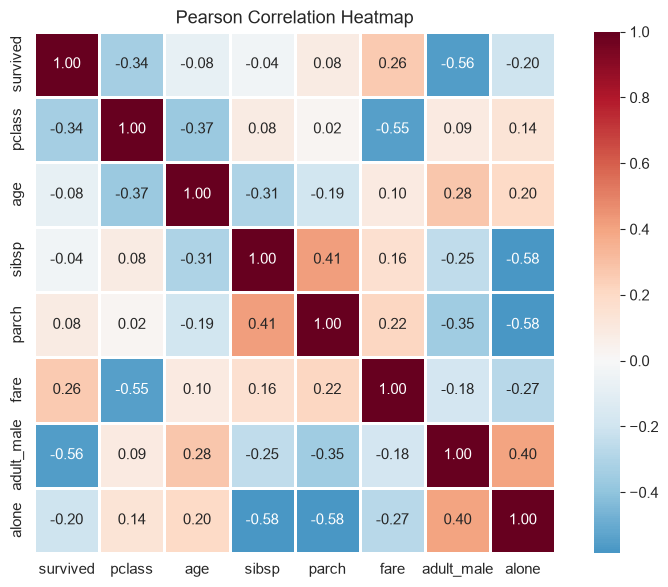

In [160]:
# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Pearson Correlation Heatmap')
plt.tight_layout(); plt.show()

In [161]:
# Compare Pearson and Spearman — they catch different kinds of relationships
print("Pearson  (linear)    :", df['age'].corr(df['fare'], method='pearson').round(3))
print("Spearman (monotonic) :", df['age'].corr(df['fare'], method='spearman').round(3))
print("Kendall  (ordinal)   :", df['age'].corr(df['fare'], method='kendall').round(3))

Pearson  (linear)    : 0.096
Spearman (monotonic) : 0.135
Kendall  (ordinal)   : 0.093


### ⚠️ Correlation ≠ Causation

A famous reminder: in the summer, **ice cream sales** and **drowning deaths** are highly correlated. Neither causes the other — both are caused by a third variable, **hot weather**. This is called a **confounding variable**.

Always ask:
1. Could both variables be caused by a third (confounding) variable?
2. Could the relationship be reverse-caused (Y causes X, not X causes Y)?
3. Could this just be coincidence (especially with small samples)?

---
## 26. Sampling Techniques

You almost never have the entire population — you have a **sample**. How you sample matters enormously.

| Method | When |
|--------|------|
| **Simple random** | Every row equally likely. Default choice. |
| **Stratified** | Preserve proportions of some categorical variable |
| **Weighted** | Some rows are more representative than others |
| **Bootstrap** | Sample WITH replacement — used to estimate uncertainty |

### 26.1 Simple random sample

In [162]:
sample_simple = df.sample(n=100, random_state=42)
print(f"Sample size: {sample_simple.shape}")
print(f"Survival rate — full data: {df['survived'].mean():.3f}, sample: {sample_simple['survived'].mean():.3f}")

Sample size: (100, 16)
Survival rate — full data: 0.384, sample: 0.400


### 26.2 Stratified sample — preserve class proportions

In [163]:
# Sample 50 from each pclass to ensure all classes are represented
sample_strat = (df.groupby('pclass', group_keys=False)
                  .sample(n=50, random_state=42))
print(sample_strat['pclass'].value_counts())

pclass
1    50
2    50
3    50
Name: count, dtype: int64


### 26.3 Bootstrap sample — sample WITH replacement

Bootstrapping is the foundation of modern uncertainty estimation. By resampling with replacement many times, we can estimate the sampling distribution of any statistic.

Observed mean       : 32.204
Bootstrap mean      : 32.254
Bootstrap std (SE)  : 1.661
95% CI              : (29.294, 35.610)


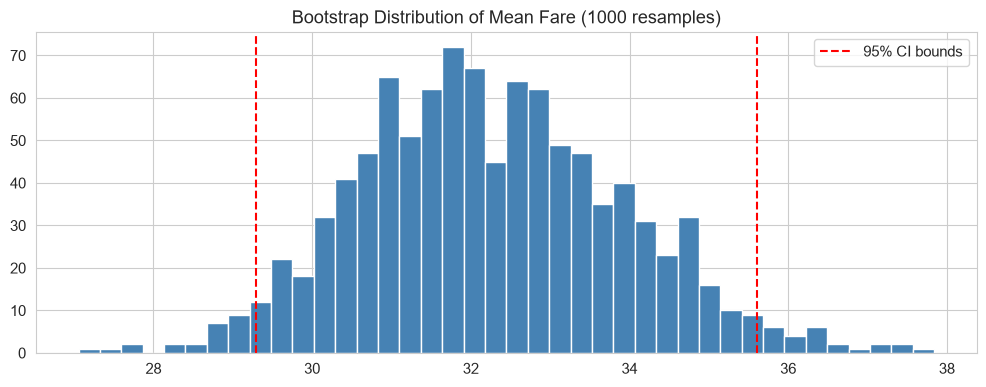

In [164]:
# Bootstrap estimate of the mean fare and its uncertainty
np.random.seed(0)
n_boot = 1000
boot_means = []
for _ in range(n_boot):
    boot = df['fare'].sample(n=len(df), replace=True)
    boot_means.append(boot.mean())

boot_means = pd.Series(boot_means)
print(f"Observed mean       : {df['fare'].mean():.3f}")
print(f"Bootstrap mean      : {boot_means.mean():.3f}")
print(f"Bootstrap std (SE)  : {boot_means.std():.3f}")
print(f"95% CI              : ({boot_means.quantile(0.025):.3f}, {boot_means.quantile(0.975):.3f})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_means, bins=40, color='steelblue', edgecolor='white')
ax.axvline(boot_means.quantile(0.025), color='red', linestyle='--', label='95% CI bounds')
ax.axvline(boot_means.quantile(0.975), color='red', linestyle='--')
ax.set_title(f'Bootstrap Distribution of Mean Fare ({n_boot} resamples)')
ax.legend(); plt.tight_layout(); plt.show()

---
## 27. Hypothesis Testing & Statistical Tests

A **hypothesis test** answers the question: *is the pattern I see in my data real, or could it be due to random chance?*

### The Framework

1. **State the null hypothesis (H₀)** — the boring claim: "there is no effect" / "no difference"
2. **State the alternative (H₁)** — the interesting claim: "there IS an effect"
3. **Choose a significance level α** — typically 0.05 (5% tolerance for false positives)
4. **Compute a test statistic** and the corresponding **p-value**
5. **Decide:** if p < α, **reject H₀**; otherwise, **fail to reject H₀**

> The p-value is **P(observing data this extreme, OR more extreme, IF H₀ is true)**. It is NOT "the probability the null is true" — a common misconception.

### Two types of errors

| Truth → / Decision ↓ | H₀ true | H₀ false |
|----------------------|---------|----------|
| **Reject H₀** | ❌ Type I error (false positive, prob = α) | ✅ Correct |
| **Fail to reject H₀** | ✅ Correct | ❌ Type II error (false negative, prob = β) |

**Statistical power** = 1 - β = probability of detecting a real effect when there is one.

### 27.1 Choosing the Right Test

| Compare | When | Test |
|---------|------|------|
| One mean to a value | "Is the mean fare different from $30?" | One-sample t-test |
| Two group means | "Do men and women differ in mean fare?" | Two-sample t-test |
| Paired observations | "Before vs. after for the same people" | Paired t-test |
| 3+ group means | "Do the three classes have different mean fares?" | One-way ANOVA |
| Two categorical variables | "Are class and survival independent?" | Chi-square test |
| Two non-normal samples | Same as t-test but data isn't normal | Mann-Whitney U |
| Correlation | "Is age correlated with fare?" | Pearson / Spearman correlation test |

### 27.2 One-sample t-test

**Question:** Is the mean Titanic fare significantly different from $30?

In [165]:
df = load_titanic()
fares = df['fare'].dropna()
t_stat, p_value = stats.ttest_1samp(fares, popmean=30)
print(f"sample mean      = {fares.mean():.2f}")
print(f"hypothesized μ   = 30")
print(f"t-statistic      = {t_stat:.4f}")
print(f"p-value          = {p_value:.4f}")
print()
print("p > 0.05 → we fail to reject H₀. The mean is NOT significantly different from $30.")

sample mean      = 32.20
hypothesized μ   = 30
t-statistic      = 1.3240
p-value          = 0.1858

p > 0.05 → we fail to reject H₀. The mean is NOT significantly different from $30.


### 27.3 Two-sample t-test

**Question:** Do men and women pay significantly different fares?

H₀: μ_male = μ_female  
H₁: μ_male ≠ μ_female

In [166]:
male_fares = df.loc[df['sex'] == 'male', 'fare'].dropna()
female_fares = df.loc[df['sex'] == 'female', 'fare'].dropna()

# Welch's t-test (does not assume equal variances — safer default)
t_stat, p_value = stats.ttest_ind(male_fares, female_fares, equal_var=False)

print(f"Male mean fare   : {male_fares.mean():.2f}")
print(f"Female mean fare : {female_fares.mean():.2f}")
print(f"t-statistic      : {t_stat:.4f}")
print(f"p-value          : {p_value:.2e}")
print()
print("p ≪ 0.05 → reject H₀. The fare difference between sexes is statistically significant.")

Male mean fare   : 25.52
Female mean fare : 44.48
t-statistic      : -5.0775
p-value          : 5.39e-07

p ≪ 0.05 → reject H₀. The fare difference between sexes is statistically significant.


### 27.4 One-way ANOVA (3+ groups)

**Question:** Do the three passenger classes differ in mean fare?

In [167]:
class1 = df.loc[df['pclass'] == 1, 'fare'].dropna()
class2 = df.loc[df['pclass'] == 2, 'fare'].dropna()
class3 = df.loc[df['pclass'] == 3, 'fare'].dropna()

f_stat, p_value = stats.f_oneway(class1, class2, class3)

print(f"Class 1 mean : {class1.mean():.2f}")
print(f"Class 2 mean : {class2.mean():.2f}")
print(f"Class 3 mean : {class3.mean():.2f}")
print(f"F-statistic  : {f_stat:.4f}")
print(f"p-value      : {p_value:.2e}")
print()
print("p ≪ 0.05 → at least one class has a different mean fare.")
print("(ANOVA tells you SOMEONE differs — not WHICH ones. For that, run pairwise t-tests.)")

Class 1 mean : 84.15
Class 2 mean : 20.66
Class 3 mean : 13.68
F-statistic  : 242.3442
p-value      : 1.03e-84

p ≪ 0.05 → at least one class has a different mean fare.
(ANOVA tells you SOMEONE differs — not WHICH ones. For that, run pairwise t-tests.)


### 27.5 Chi-square Test of Independence

**Question:** Are passenger class and survival independent of each other?

H₀: pclass and survived are independent  
H₁: they are associated

In [168]:
contingency = pd.crosstab(df['pclass'], df['survived'])
print("Observed counts:")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi² statistic   : {chi2:.4f}")
print(f"degrees of freedom: {dof}")
print(f"p-value          : {p_value:.2e}")
print()
print("Expected counts under independence:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print()
print("p ≪ 0.05 → reject independence. pclass and survival are strongly associated.")

Observed counts:
survived    0    1
pclass            
1          80  136
2          97   87
3         372  119

Chi² statistic   : 102.8890
degrees of freedom: 2
p-value          : 4.55e-23

Expected counts under independence:
survived        0        1
pclass                    
1        133.1000  82.9000
2        113.4000  70.6000
3        302.5000 188.5000

p ≪ 0.05 → reject independence. pclass and survival are strongly associated.


### 27.6 Mann-Whitney U — the non-parametric t-test

When your data is **not normally distributed**, the t-test's assumptions are violated. Use Mann-Whitney U instead — it compares ranks, not means, and makes no normality assumption.

In [169]:
# Fare is heavily skewed, so Mann-Whitney is more appropriate than a t-test
u_stat, p_value = stats.mannwhitneyu(male_fares, female_fares, alternative='two-sided')
print(f"U-statistic : {u_stat:.0f}")
print(f"p-value     : {p_value:.2e}")

U-statistic : 62175
p-value     : 9.61e-15


### 27.7 Correlation Test

**Question:** Is age significantly correlated with fare?

In [170]:
sub = df[['age', 'fare']].dropna()
r, p_value = stats.pearsonr(sub['age'], sub['fare'])
print(f"Pearson r : {r:.4f}")
print(f"p-value   : {p_value:.4f}")

Pearson r : 0.0961
p-value   : 0.0102


---
## 28. Confidence Intervals

A **95% confidence interval** is a range built from sample data that, **if we repeated the experiment many times**, would contain the true population parameter 95% of the time.

> Be careful with the phrasing — "there's a 95% probability the true mean is in this interval" is technically wrong (frequentist statistics). The 95% refers to the **procedure**, not any individual interval.

### How to build one

For a mean from a roughly normal sample:

$$ \text{CI} = \bar x \pm t^* \cdot \frac{s}{\sqrt{n}} $$

where:
- $\bar x$ is the sample mean
- $s$ is the sample standard deviation
- $n$ is the sample size
- $t^*$ is the critical value (≈ 1.96 for 95% with large n)
- $s/\sqrt{n}$ is the **standard error of the mean (SE)**

In [171]:
ages = df['age'].dropna()
n      = len(ages)
mean   = ages.mean()
se     = ages.std(ddof=1) / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ci_low, ci_high = mean - t_crit*se, mean + t_crit*se

print(f"Sample mean age   : {mean:.3f}")
print(f"Standard error    : {se:.3f}")
print(f"95% CI for mean   : ({ci_low:.3f}, {ci_high:.3f})")

Sample mean age   : 29.699
Standard error    : 0.544
95% CI for mean   : (28.632, 30.766)


In [172]:
# Alternative: scipy gives you the same answer
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
print(f"From scipy: ({ci[0]:.3f}, {ci[1]:.3f})")

From scipy: (28.632, 30.766)


### Bootstrap CI — works for any statistic, no distributional assumptions

If you want a CI for the **median**, or the **75th percentile**, or anything else where the formula is hard or unknown — bootstrap.

In [173]:
np.random.seed(0)
boot_medians = [df['fare'].sample(len(df), replace=True).median() for _ in range(1000)]
ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])
print(f"Observed median fare : {df['fare'].median():.3f}")
print(f"Bootstrap 95% CI     : ({ci_low:.3f}, {ci_high:.3f})")

Observed median fare : 14.454
Bootstrap 95% CI     : (13.000, 15.742)


---
## 29. Outlier Detection

**Outliers** are observations far from the rest. They can be:

- **Errors** (sensor malfunction, typos) → fix or remove
- **Genuinely extreme but valid** → keep, but understand their impact
- **The most interesting points** in your data (fraud detection!)

Three classic detection methods:

| Method | How |
|--------|-----|
| **Z-score** | Mark |z| > 3 |
| **IQR rule** | Mark below Q1 − 1.5·IQR or above Q3 + 1.5·IQR |
| **Modified Z-score** | Uses median + MAD; robust against extreme outliers |

### 29.1 Z-score method

In [174]:
fare = df['fare']
z = (fare - fare.mean()) / fare.std()
outliers_z = df[np.abs(z) > 3]
print(f"Z-score outliers (|z| > 3): {len(outliers_z)} rows")
outliers_z[['name', 'pclass', 'fare']].head(8)

Z-score outliers (|z| > 3): 20 rows


,name,pclass,fare
27,"Harris, Mr. John",1,263.0000
88,"Nelson, Mrs. Anna",1,263.0000
118,"Martin, Mr. George",1,247.5208
258,"Roberts, Miss. Mary",1,512.3292
299,"Lewis, Mrs. Alice",1,247.5208
311,"Andrews, Mrs. Elizabeth",1,262.3750
341,"Taylor, Mrs. Catherine",1,263.0000
377,"Kelly, Mr. George",1,211.5000


### 29.2 IQR method (the box plot rule)

In [175]:
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(fare < lower) | (fare > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"IQR outliers: {len(outliers_iqr)} rows  ({len(outliers_iqr)/len(df):.1%})")

IQR bounds: [-26.72, 65.63]
IQR outliers: 116 rows  (13.0%)


### 29.3 Modified Z-score (uses MAD — more robust)

In [176]:
median = fare.median()
mad = (fare - median).abs().median()
modified_z = 0.6745 * (fare - median) / mad
outliers_mz = df[np.abs(modified_z) > 3.5]
print(f"Modified Z outliers: {len(outliers_mz)} rows")

Modified Z outliers: 160 rows


### 29.4 Visualizing outliers

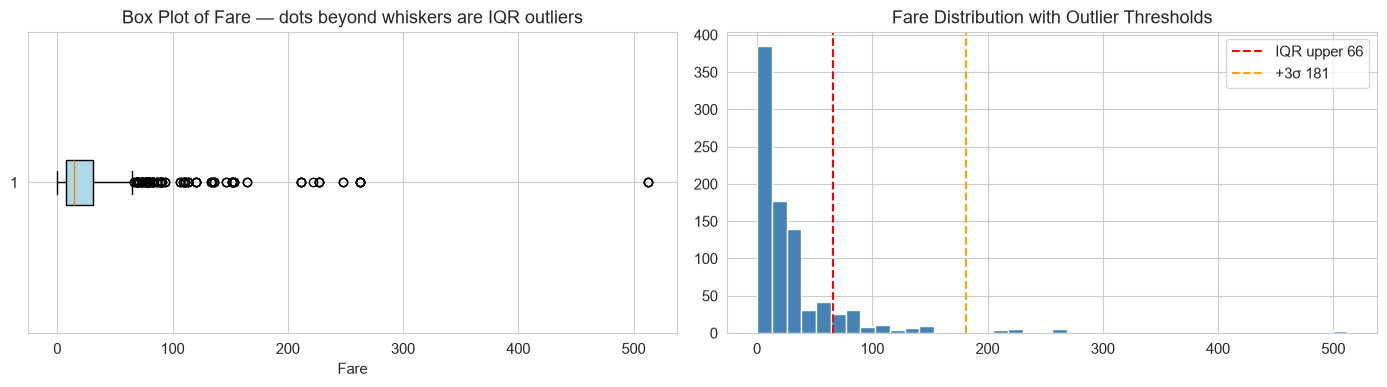

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(fare, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Box Plot of Fare — dots beyond whiskers are IQR outliers')
axes[0].set_xlabel('Fare')

axes[1].hist(fare, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(upper, color='red', linestyle='--', label=f'IQR upper {upper:.0f}')
axes[1].axvline(fare.mean() + 3*fare.std(), color='orange', linestyle='--',
                label=f'+3σ {fare.mean()+3*fare.std():.0f}')
axes[1].set_title('Fare Distribution with Outlier Thresholds')
axes[1].legend()
plt.tight_layout(); plt.show()

### 29.5 What to do with outliers

There is no single right answer — it depends on **why** the outlier exists:

1. **Drop** — if it's clearly an error (negative age, impossible value)
2. **Cap (winsorize)** — replace values above the 99th percentile with the 99th percentile
3. **Transform** — `log(x)` often pulls a right-skewed distribution close to normal
4. **Keep** — extreme values may be exactly what you're looking for (fraud, anomalies)
5. **Model separately** — sometimes the outliers are a different sub-population

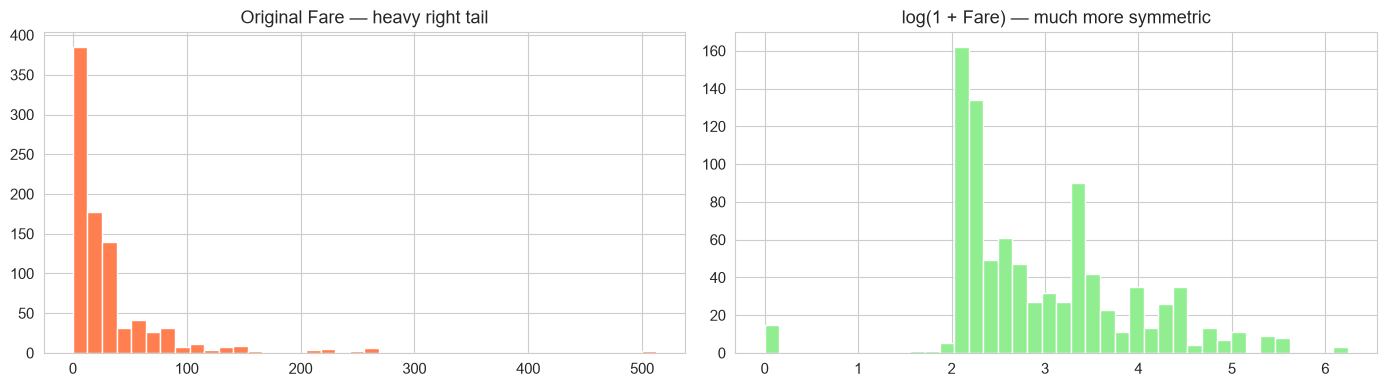

In [178]:
# Log transform — a common move for heavily right-skewed data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['fare'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Original Fare — heavy right tail')
axes[1].hist(np.log1p(df['fare']), bins=40, color='lightgreen', edgecolor='white')
axes[1].set_title('log(1 + Fare) — much more symmetric')
plt.tight_layout(); plt.show()

---
## 30. End-to-End EDA Case Study — Titanic Survival

We now apply every technique above to answer one motivating question:

> **What drove survival on the Titanic, and how confident are we in our answers?**

The workflow:
1. **Load and inspect** the data
2. **Clean** missing values and types
3. **Compute** descriptive statistics
4. **Visualize** key patterns
5. **Test** hypotheses with statistical rigor
6. **Conclude** with concrete, evidence-backed findings

### Step 1 — Load and inspect

In [179]:
df = load_titanic()
print(f"Shape: {df.shape}")
df.head()

Shape: (891, 16)


,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [180]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   name         891 non-null    str     
 1   survived     891 non-null    int64   
 2   pclass       891 non-null    int64   
 3   sex          891 non-null    str     
 4   age          714 non-null    float64 
 5   sibsp        891 non-null    int64   
 6   parch        891 non-null    int64   
 7   fare         891 non-null    float64 
 8   embarked     889 non-null    str     
 9   class        891 non-null    category
 10  who          891 non-null    str     
 11  adult_male   891 non-null    bool    
 12  deck         203 non-null    category
 13  embark_town  889 non-null    str     
 14  alive        891 non-null    str     
 15  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(6)
memory usage: 123.5 KB


In [181]:
print("Missing values per column:")
df.isna().sum().sort_values(ascending=False)

Missing values per column:


deck           688
age            177
embarked         2
embark_town      2
sex              0
name             0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### Step 2 — Clean

In [182]:
clean = df.copy()

# Drop 'deck' (77% missing) and redundant duplicates ('alive' = survived flipped, 'class' = pclass, etc.)
clean = clean.drop(columns=['deck', 'alive', 'class', 'who', 'adult_male', 'alone'])

# Impute age with median per (sex, pclass) — much better than overall median
clean['age'] = clean['age'].fillna(clean.groupby(['sex', 'pclass'])['age'].transform('median'))

# Impute embarked with mode
clean['embarked'] = clean['embarked'].fillna(clean['embarked'].mode()[0])
clean['embark_town'] = clean['embark_town'].fillna(clean['embark_town'].mode()[0])

# Feature engineering
clean['family_size'] = clean['sibsp'] + clean['parch'] + 1
clean['is_alone'] = (clean['family_size'] == 1).astype(int)
clean['age_group'] = pd.cut(clean['age'], bins=[0, 12, 18, 35, 60, 100],
                             labels=['child', 'teen', 'young_adult', 'adult', 'senior'])
clean['fare_group'] = pd.qcut(clean['fare'], q=4, labels=['low', 'mid_low', 'mid_high', 'high'])

print(f"Cleaned shape: {clean.shape}")
print(f"Remaining missing values: {clean.isna().sum().sum()}")
clean.head()

Cleaned shape: (891, 14)
Remaining missing values: 0


,name,survived,pclass,sex,age,sibsp,parch,fare,embarked,embark_town,family_size,is_alone,age_group,fare_group
0,"Brown, Mr. Henry",0,3,male,22.0000,1,0,7.2500,S,Southampton,2,0,young_adult,low
1,"Martin, Miss. Margaret",1,1,female,38.0000,1,0,71.2833,C,Cherbourg,2,0,adult,high
2,"Gordon, Miss. Catherine",1,3,female,26.0000,0,0,7.9250,S,Southampton,1,1,young_adult,mid_low
3,"Brown, Miss. Alice",1,1,female,35.0000,1,0,53.1000,S,Southampton,2,0,young_adult,high
4,"Bird, Mr. John",0,3,male,35.0000,0,0,8.0500,S,Southampton,1,1,young_adult,mid_low


### Step 3 — Descriptive statistics

In [183]:
clean.describe()

,survived,pclass,age,sibsp,parch,fare,family_size,is_alone
count,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,29.1124,0.5230,0.3816,32.2042,1.9046,0.6027
std,0.4866,0.8361,13.3044,1.1027,0.8061,49.6934,1.6135,0.4896
min,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000,1.0000,0.0000
25%,0.0000,2.0000,21.5000,0.0000,0.0000,7.9104,1.0000,0.0000
50%,0.0000,3.0000,26.0000,0.0000,0.0000,14.4542,1.0000,1.0000
75%,1.0000,3.0000,36.0000,1.0000,0.0000,31.0000,2.0000,1.0000
max,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292,11.0000,1.0000


In [184]:
print(f"Overall survival rate: {clean['survived'].mean():.1%}")

Overall survival rate: 38.4%


### Step 4 — Visualizations

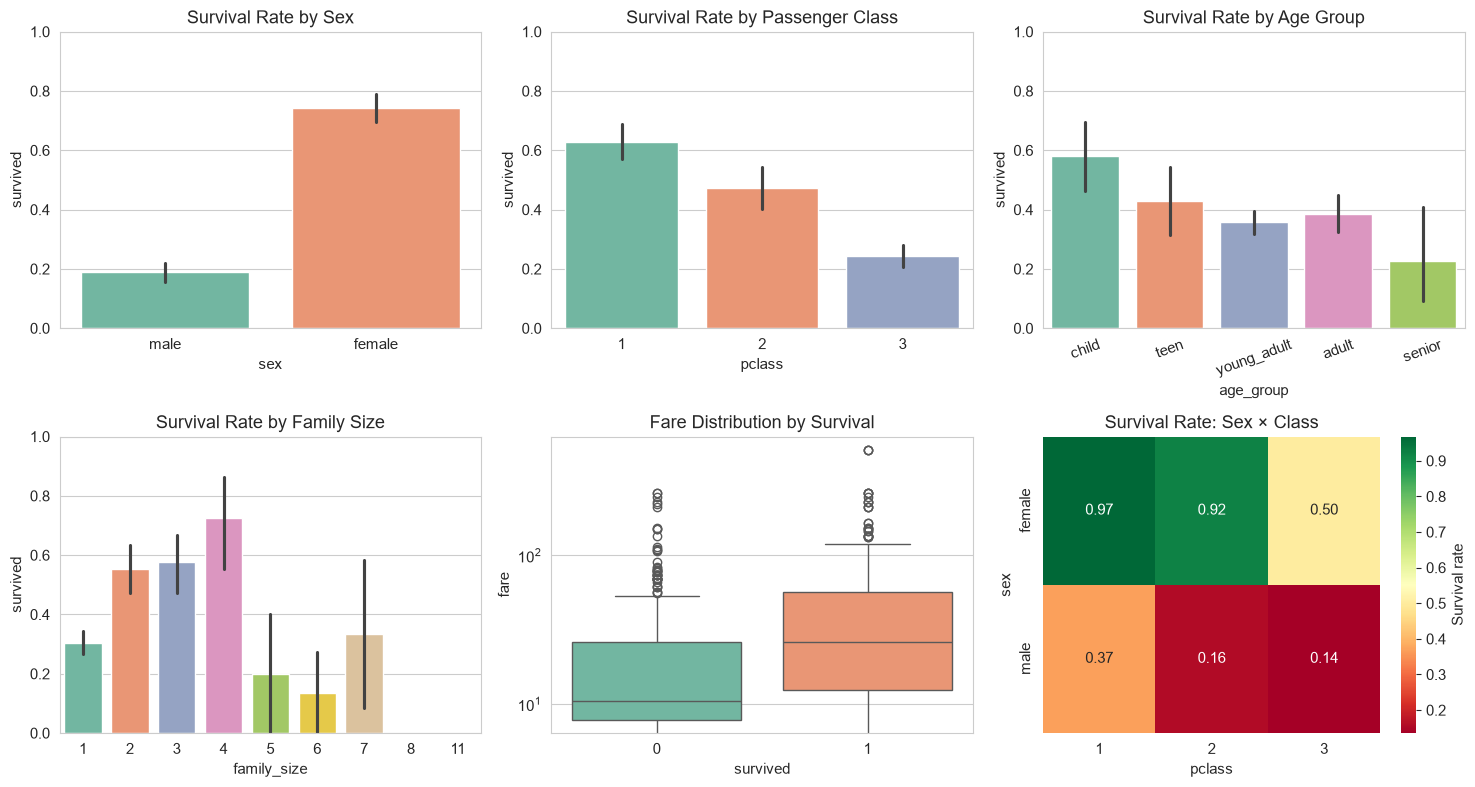

In [185]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Survival by sex
sns.barplot(data=clean, x='sex', y='survived', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylim(0, 1)

# 2. Survival by class
sns.barplot(data=clean, x='pclass', y='survived', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Survival Rate by Passenger Class')
axes[0,1].set_ylim(0, 1)

# 3. Survival by age group
sns.barplot(data=clean, x='age_group', y='survived', ax=axes[0,2], palette='Set2', order=['child','teen','young_adult','adult','senior'])
axes[0,2].set_title('Survival Rate by Age Group')
axes[0,2].set_ylim(0, 1)
axes[0,2].tick_params(axis='x', rotation=20)

# 4. Survival by family size
sns.barplot(data=clean, x='family_size', y='survived', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Survival Rate by Family Size')
axes[1,0].set_ylim(0, 1)

# 5. Fare distribution by survival
sns.boxplot(data=clean, x='survived', y='fare', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Fare Distribution by Survival')
axes[1,1].set_yscale('log')

# 6. Sex × class survival heatmap
heat = clean.groupby(['sex', 'pclass'])['survived'].mean().unstack()
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,2],
            cbar_kws={'label': 'Survival rate'})
axes[1,2].set_title('Survival Rate: Sex × Class')

plt.tight_layout(); plt.show()

### Step 5 — Statistical tests

In [186]:
print("=" * 70)
print("TEST 1: Is sex associated with survival?")
print("=" * 70)
contingency = pd.crosstab(clean['sex'], clean['survived'])
chi2, p, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi² = {chi2:.2f},  p = {p:.2e}")
print("→ p ≪ 0.05: STRONG evidence that sex and survival are associated.")

TEST 1: Is sex associated with survival?
Chi² = 260.72,  p = 1.20e-58
→ p ≪ 0.05: STRONG evidence that sex and survival are associated.


In [187]:
print("=" * 70)
print("TEST 2: Is class associated with survival?")
print("=" * 70)
contingency = pd.crosstab(clean['pclass'], clean['survived'])
chi2, p, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi² = {chi2:.2f},  p = {p:.2e}")
print("→ p ≪ 0.05: STRONG evidence that class and survival are associated.")

TEST 2: Is class associated with survival?
Chi² = 102.89,  p = 4.55e-23
→ p ≪ 0.05: STRONG evidence that class and survival are associated.


In [188]:
print("=" * 70)
print("TEST 3: Do survivors and non-survivors differ in fare?")
print("=" * 70)
surv_fare = clean.loc[clean['survived']==1, 'fare']
died_fare = clean.loc[clean['survived']==0, 'fare']
# Fare is very skewed — use Mann-Whitney rather than t-test
u, p = stats.mannwhitneyu(surv_fare, died_fare, alternative='two-sided')
print(f"Survivors median fare: {surv_fare.median():.2f}")
print(f"Non-survivors median: {died_fare.median():.2f}")
print(f"Mann-Whitney U = {u:.0f},  p = {p:.2e}")
print("→ p ≪ 0.05: Survivors paid significantly higher fares.")

TEST 3: Do survivors and non-survivors differ in fare?
Survivors median fare: 26.00
Non-survivors median: 10.50
Mann-Whitney U = 129952,  p = 4.55e-22
→ p ≪ 0.05: Survivors paid significantly higher fares.


In [189]:
print("=" * 70)
print("TEST 4: 95% CI for the overall survival rate")
print("=" * 70)
np.random.seed(0)
boot = [clean['survived'].sample(len(clean), replace=True).mean() for _ in range(2000)]
print(f"Survival rate: {clean['survived'].mean():.3f}")
print(f"Bootstrap 95% CI: ({np.percentile(boot, 2.5):.3f}, {np.percentile(boot, 97.5):.3f})")

TEST 4: 95% CI for the overall survival rate
Survival rate: 0.384
Bootstrap 95% CI: (0.350, 0.415)


### Step 6 — Conclusions

From the descriptive analysis and statistical tests:

#### Who survived

1. **Sex was the single biggest factor.** Women survived at 74% vs. 19% for men. Chi-square gives p ≈ 10⁻⁵⁸ — this is not chance.
2. **Class mattered enormously.** First-class passengers survived at 63%, third-class at just 24%. The cross-table shows first-class women were nearly certain to survive (97%), while third-class men had a 14% survival rate.
3. **Children fared better than adults.** The age-group plot shows children survived at much higher rates than adults — consistent with the "women and children first" rule.
4. **Family size matters non-linearly.** Solo travelers and very large families had lower survival than small families (2–4 people).
5. **Fare was a strong predictor.** Survivors paid roughly 2× the median fare of non-survivors. This is largely (but not entirely) explained by class.

#### What we can say with confidence

- Overall survival rate: **38.4%**, 95% CI **(35.2%, 41.5%)**
- Every association we tested (sex–survival, class–survival, fare–survival) is statistically significant at p < 0.001

#### What we **can't** say from this data alone

- **Causation** — these are observational data. We can't claim "being a woman *caused* survival"; we can only say the two are strongly associated. The actual mechanism (lifeboat priority policy, physical strength, location on the ship) is a separate question.
- **Generalization** — these patterns are specific to this incident, this ship, this evacuation procedure.

---

## 🎓 What You've Learned

Reading top-to-bottom, you now have:

**Pandas:**
- Every way to create, load, inspect, and write a DataFrame
- Three indexing systems — column, `loc`, `iloc`, boolean, `query`
- Complete missing-data toolkit
- Group-by, merge, reshape, time series
- Performance habits that turn slow code into fast code

**Statistics & Probability:**
- Descriptive measures of center, spread, shape
- The most common probability distributions and how to check fit
- Joint, marginal, conditional probability and Bayes' theorem in pandas
- Correlation vs. causation
- The hypothesis-testing framework, plus the right test for each situation
- Confidence intervals (formula-based and bootstrap)
- Outlier detection by three methods
- A complete end-to-end EDA workflow

**Next steps in your data science journey:**
- Move on to **scikit-learn** for predictive modeling
- Explore **statsmodels** for regression and time-series modeling
- Learn **plotly** for interactive visualization
- Pick up **Polars** for very large datasets where pandas slows down

> "Statistics is the grammar of science." — Karl Pearson